# Order Imbalance Research (Shen 2015 Replication)

CFFEX IF futures tick data — DuckDB pipeline, OLS signal, Strategy A & B backtest

## 0. Overview

In [1]:
import sys
import os
import pathlib

# Set working directory to project root so DB_PATH in load_data.py resolves correctly.
ROOT = pathlib.Path().resolve().parent
os.chdir(ROOT)

# Add project root and src/ to sys.path for module imports.
for p in [str(ROOT), str(ROOT / 'src')]:
    if p not in sys.path:
        sys.path.insert(0, p)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import duckdb

from load_data import db_summary, load_date_range
from backtest_engine import (
    run_backtest,
    compute_performance_metrics,
    run_parameter_sweep,
    plot_results,
    fit_ols_model,
    compute_signals,
)

%matplotlib inline
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
pd.set_option("display.max_columns", None)


In [2]:
def signal_diagnostics(features_df, feature_cols, sorted_days, q_grid):
    """Per-day OLS signal stats. Returns DataFrame with sig_mean, sig_std,
    sig_p50/p90/p95/p99, n_ticks, trigger_{q} and pctile_{q} for each q."""
    records = []
    for i, day in enumerate(sorted_days):
        if i == 0:
            continue
        prev_day = sorted_days[i - 1]
        train_df = features_df[features_df[DAY_COL] == prev_day]
        coefs = fit_ols_model(train_df[feature_cols].values, train_df[TARGET_COL].values)
        if coefs is None:
            continue
        test_df = features_df[features_df[DAY_COL] == day]
        signals = compute_signals(test_df[feature_cols].values, coefs)
        sig_abs = np.abs(signals)
        rec = {
            'TradDay':  day,
            'sig_mean': float(np.mean(signals)),
            'sig_std':  float(np.std(signals)),
            'sig_p50':  float(np.percentile(sig_abs, 50)),
            'sig_p90':  float(np.percentile(sig_abs, 90)),
            'sig_p95':  float(np.percentile(sig_abs, 95)),
            'sig_p99':  float(np.percentile(sig_abs, 99)),
            'n_ticks':  len(signals),
        }
        for qv in q_grid:
            rec[f'trigger_{qv}'] = float(np.mean(sig_abs >= qv))
            rec[f'pctile_{qv}']  = float(np.mean(sig_abs < qv))
        records.append(rec)
    return pd.DataFrame(records)

## 1. Database Setup

In [3]:
db_summary()

📊 数据库概况
   总行数     : 30,558,059
   交易天数   : 60
   合约数量   : 44
   最早日期   : 20260202
   最新日期   : 20260508
   DB 文件    : data\market_data.db (2467.3 MB)


## 2. Data Loading, Filtering & Cleaning

### 2.1 Load Raw Data

In [4]:
df = load_date_range(20260202, 20260508, columns=[
    "InstruID",
    "TradDay",
    "ActionDateTime",
    "BidPrice1", "BidVolume1",
    "AskPrice1", "AskVolume1",
    "Volume",
    "Turnover",
    "OpenInt"
])

df.head()

,InstruID,TradDay,ActionDateTime,BidPrice1,BidVolume1,AskPrice1,AskVolume1,Volume,Turnover,OpenInt
0,TL2603,20260202,20260202 09:29:00.400,112.150002,4,112.160004,1,63,70654500.0,134760.0
1,TL2606,20260202,20260202 09:29:00.400,112.239998,30,112.250000,1,31,34794400.0,43949.0
2,TL2609,20260202,20260202 09:29:00.400,111.919998,2,112.019997,1,0,0.0,2594.0
3,TS2606,20260202,20260202 09:29:00.400,102.412003,5,102.430000,5,0,0.0,9944.0
4,TS2609,20260202,20260202 09:29:00.400,102.416000,20,102.486000,20,0,0.0,988.0


In [5]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df.duplicated().sum())

(30558059, 10)
InstruID              str
TradDay             int32
ActionDateTime        str
BidPrice1         float32
BidVolume1          int32
AskPrice1         float32
AskVolume1          int32
Volume              int32
Turnover          float64
OpenInt           float32
dtype: object
InstruID          0
TradDay           0
ActionDateTime    0
BidPrice1         0
BidVolume1        0
AskPrice1         0
AskVolume1        0
Volume            0
Turnover          0
OpenInt           0
dtype: int64
0


In [6]:
# Parse ActionDateTime to datetime; microsecond precision covers overnight sessions.
df['ActionDateTime'] = pd.to_datetime(df['ActionDateTime'], format='%Y%m%d %H:%M:%S.%f')

df['time_seconds'] = (
    df['ActionDateTime'].dt.hour * 3600 +
    df['ActionDateTime'].dt.minute * 60 +
    df['ActionDateTime'].dt.second +
    df['ActionDateTime'].dt.microsecond / 1_000_000
)


### 2.2 Initial Exploration

In [7]:
# Check 1: session time-window coverage.
morning_mask = (df['time_seconds'] >= 33300) & (df['time_seconds'] < 41280)
afternoon_mask = (df['time_seconds'] >= 46800) & (df['time_seconds'] < 54780)

print("Morning rows:", morning_mask.sum())
print("Afternoon rows:", afternoon_mask.sum())
print("Outside session:", (~morning_mask & ~afternoon_mask).sum())

# Check 2: timestamps are monotonically increasing within each (contract, day).
for (instru, day), grp in df.groupby(['InstruID', 'TradDay']):
    if not grp['ActionDateTime'].is_monotonic_increasing:
        print(f"{instru} {day} timestamps not monotonic!")

# Check 3: tick interval distribution (expect ~0.5 s).
# Group by (InstruID, TradDay) and diff time_seconds; dt=0 indicates duplicate ticks.
df_sorted = df.sort_values(['InstruID', 'TradDay', 'ActionDateTime']).reset_index(drop=True)
df_sorted['dt'] = df_sorted.groupby(['InstruID', 'TradDay'])['time_seconds'].diff()
print(df_sorted['dt'].round(1).value_counts().sort_index())
# Dominant values should be 0.5 s and 1.0 s; ~5400 s gaps are open/close session boundaries.

# Check 4: crossed or zero-priced order book rows.
crossed = (df['BidPrice1'] >= df['AskPrice1'])
zero_bid = (df['BidPrice1'] == 0)
zero_ask = (df['AskPrice1'] == 0)
print("Crossed book rows:", crossed.sum())
print("Zero BidPrice1:", zero_bid.sum())
print("Zero AskPrice1:", zero_ask.sum())


Morning rows: 15549621
Afternoon rows: 14672832
Outside session: 335606
dt
0.5       26382117
1.0        1784971
1.5         771929
2.0         424842
2.5         270425
            ...   
5409.0           3
5409.5           1
5413.0           1
5415.0           1
6756.5           1
Name: count, Length: 613, dtype: int64
Crossed book rows: 11
Zero BidPrice1: 13
Zero AskPrice1: 11


In [8]:
print(df['InstruID'].unique())

# Keep only IF contracts; exclude IC, IH, etc.
df_IF = df[df['InstruID'].str.startswith('IF')]
print(f"IF contract rows: {len(df_IF)}")
print(f"Non-IF rows: {len(df) - len(df_IF)}")


<StringArray>
['TL2603', 'TL2606', 'TL2609', 'TS2606', 'TS2609', 'TS2603', 'IF2603',
 'IF2606', 'IH2602', 'IF2609', 'IH2603', 'IH2606', 'IH2609', 'IM2603',
 'IM2602', 'IM2606', 'IM2609',  'T2603',  'T2609', 'TF2603', 'TF2609',
  'T2606', 'TF2606', 'IC2602', 'IC2606', 'IF2602', 'IC2603', 'IC2609',
 'IC2604', 'IM2604', 'IF2604', 'IH2604',  'T2612', 'TL2612', 'TF2612',
 'TS2612', 'IM2605', 'IC2605', 'IF2605', 'IH2605', 'IM2612', 'IF2612',
 'IH2612', 'IC2612']
Length: 44, dtype: str
IF contract rows: 5393563
Non-IF rows: 25164496


### 2.3 Data Cleaning

In [9]:
print(f"Raw df: {len(df)} rows")

# Step 1: keep only IF contracts.
df_clean = df[df['InstruID'].str.startswith('IF')].reset_index(drop=True)
print(f"After IF filter: {len(df_clean)} rows")

# Step 2: restrict to trading session hours (morning / afternoon).
# Check 1 confirmed non-session rows; Check 3 confirmed ~5400 s gaps are session boundaries.
morning_mask = (df_clean['time_seconds'] >= 33300) & (df_clean['time_seconds'] < 41280)
afternoon_mask = (df_clean['time_seconds'] >= 46800) & (df_clean['time_seconds'] < 54780)
df_clean = df_clean[morning_mask | afternoon_mask].reset_index(drop=True)
print(f"After session filter: {len(df_clean)} rows")

# Step 3: drop crossed book and zero-price rows.
# Check 4 confirmed these exist and need removal.
crossed = (df_clean['BidPrice1'] >= df_clean['AskPrice1'])
zero_bid = (df_clean['BidPrice1'] == 0)
zero_ask = (df_clean['AskPrice1'] == 0)
df_clean = df_clean[~crossed & ~zero_bid & ~zero_ask].reset_index(drop=True)
print(f"After crossed/zero filter: {len(df_clean)} rows")


Raw df: 30558059 rows
After IF filter: 5393563 rows
After session filter: 5350704 rows
After crossed/zero filter: 5350704 rows


### 2.4 Main Contract Selection

In [10]:
# Step 1: identify daily dominant contract by cumulative volume (proxy: daily max Volume).
daily_vol = (
    df_clean.groupby(['TradDay', 'InstruID'])['Volume']
    .max()
    .unstack('InstruID')
)

# Use previous day's volume (T-1 shift) to select today's main contract — avoids look-ahead bias.
prev_day_vol = daily_vol.shift(1)
valid_rows = prev_day_vol.notna().any(axis=1)
main_contract_by_day = prev_day_vol[valid_rows].idxmax(axis=1).rename('main_contract')
main_contract_by_day = main_contract_by_day.dropna()

print('Main contract by day (T-1 volume selection):')
print(main_contract_by_day.to_string())

df_main = df_clean[
    df_clean['TradDay'].isin(main_contract_by_day.index) &
    (df_clean['InstruID'] == df_clean['TradDay'].map(main_contract_by_day))
].reset_index(drop=True)

print()
print('df_main: {} rows, {} trading days'.format(len(df_main), df_main['TradDay'].nunique()))


Main contract by day (T-1 volume selection):
TradDay
20260203    IF2603
20260204    IF2603
20260205    IF2603
20260206    IF2603
20260209    IF2603
20260210    IF2603
20260211    IF2603
20260212    IF2603
20260213    IF2603
20260224    IF2603
20260225    IF2603
20260226    IF2603
20260227    IF2603
20260302    IF2603
20260303    IF2603
20260304    IF2603
20260305    IF2603
20260306    IF2603
20260309    IF2603
20260310    IF2603
20260311    IF2603
20260312    IF2603
20260313    IF2603
20260316    IF2603
20260317    IF2603
20260318    IF2603
20260319    IF2603
20260320    IF2606
20260323    IF2606
20260324    IF2606
20260325    IF2606
20260326    IF2606
20260327    IF2606
20260330    IF2606
20260331    IF2606
20260401    IF2606
20260402    IF2606
20260403    IF2606
20260407    IF2606
20260408    IF2606
20260409    IF2606
20260410    IF2606
20260413    IF2606
20260414    IF2606
20260415    IF2606
20260416    IF2606
20260417    IF2606
20260420    IF2606
20260421    IF2606
20260422    IF26

## 3. Feature Construction

### 3.1 Mid-Price Calculation

In [11]:
df_main["MidPrice"] = (df_main["BidPrice1"] + df_main["AskPrice1"]) / 2
df_main["Spread"] = df_main["AskPrice1"] - df_main["BidPrice1"]
df_main.head()

,InstruID,TradDay,ActionDateTime,BidPrice1,BidVolume1,AskPrice1,AskVolume1,Volume,Turnover,OpenInt,time_seconds,MidPrice,Spread
0,IF2603,20260203,2026-02-03 09:29:00.300,4621.000000,164,4621.399902,10,605,8.387115e+08,174521.0,34140.3,4621.200195,0.399902
1,IF2603,20260203,2026-02-03 09:30:00.300,4625.000000,8,4625.200195,10,771,1.068939e+09,174484.0,34200.3,4625.100098,0.200195
2,IF2603,20260203,2026-02-03 09:30:00.800,4627.200195,1,4628.000000,18,986,1.367306e+09,174374.0,34200.8,4627.600098,0.799805
3,IF2603,20260203,2026-02-03 09:30:01.300,4628.399902,1,4630.000000,20,1145,1.588077e+09,174251.0,34201.3,4629.200195,1.600098
4,IF2603,20260203,2026-02-03 09:30:01.800,4630.000000,7,4631.000000,10,1253,1.738117e+09,174178.0,34201.8,4630.500000,1.000000


### 3.2 VOI (Volume Order Imbalance)

In [12]:
def compute_VOI(df: pd.DataFrame) -> pd.Series:
    """Compute VOI for one (TradDay, session) slice; first row is NaN (no prior snapshot)."""
    bid_p, bid_v = df['BidPrice1'], df['BidVolume1']
    ask_p, ask_v = df['AskPrice1'], df['AskVolume1']

    d_bid_p = bid_p.diff()   # NaN at session row 0
    d_ask_p = ask_p.diff()

    # Bid side:
    #   price up   -> add full new volume (new liquidity entered above old level)
    #   price flat -> net volume change at same price level (partial queue movement)
    #   price down -> 0 (bid orders cancelled)
    subtract_bid = bid_v.shift(1).where(d_bid_p == 0, other=0.0)
    delta_VB = (bid_v - subtract_bid) * (d_bid_p >= 0)

    # Ask side:
    #   price down -> add full new volume (new liquidity entered below old level)
    #   price flat -> net volume change at same price level
    #   price up   -> 0 (ask orders cancelled)
    subtract_ask = ask_v.shift(1).where(d_ask_p == 0, other=0.0)
    delta_VA = (ask_v - subtract_ask) * (d_ask_p <= 0)

    voi = (delta_VB - delta_VA).rename('VOI')
    voi.iloc[0] = np.nan   # no prior snapshot at session open
    return voi


# Tag each tick with its session; df_clean session filter already excludes non-session rows.
df_main['session'] = np.where(df_main['time_seconds'] < 46800, 'morning', 'afternoon')

# Compute VOI independently per (TradDay, session) to avoid cross-boundary contamination.
df_main['VOI'] = (
    df_main.groupby(['TradDay', 'session'], group_keys=False)
    .apply(compute_VOI)
)

n_valid = df_main['VOI'].notna().sum()
n_nan   = df_main['VOI'].isna().sum()
print(f"VOI computed: {n_valid:,} valid ticks, {n_nan} NaN (one per session start)")


VOI computed: 1,559,142 valid ticks, 118 NaN (one per session start)


     BidPrice1  BidVolume1    AskPrice1  AskVolume1   VOI
0  4621.000000         164  4621.399902          10   NaN
1  4625.000000           8  4625.200195          10   8.0
2  4627.200195           1  4628.000000          18   1.0
3  4628.399902           1  4630.000000          20   1.0
4  4630.000000           7  4631.000000          10   7.0
5  4630.000000          55  4631.000000           1  57.0
6  4633.000000           2  4633.600098          12   2.0
7  4631.200195           3  4632.799805           1  -1.0
8  4631.000000          23  4632.200195           1  -1.0
9  4631.000000           6  4631.399902           2 -19.0

[OK] NaN assertions passed
mean=-0.13  std=5.21  min=-193  max=86


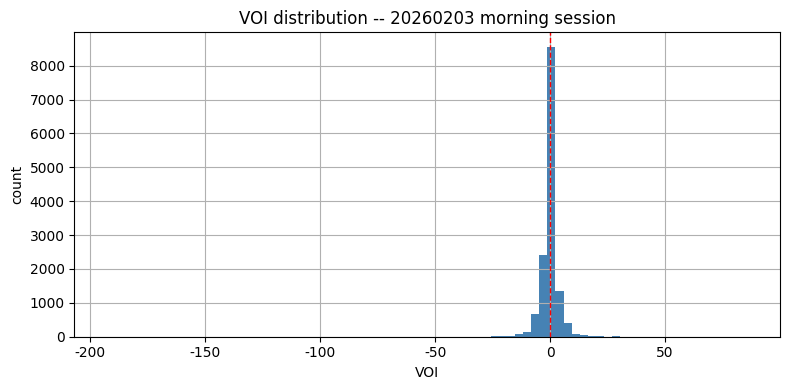

In [13]:
# ---- Sanity check ---------------------------------------------------------------
first_day = df_main['TradDay'].min()
sample = df_main[(df_main['TradDay'] == first_day) & (df_main['session'] == 'morning')]

print(sample[['BidPrice1', 'BidVolume1', 'AskPrice1', 'AskVolume1', 'VOI']].head(10).to_string())
print()

assert pd.isna(sample['VOI'].iloc[0]),        "FAIL: first row is not NaN"
assert sample['VOI'].iloc[1:].notna().all(),   "FAIL: NaN found after first row"
print("[OK] NaN assertions passed")

voi_vals = sample['VOI'].dropna()
print(f"mean={voi_vals.mean():.2f}  std={voi_vals.std():.2f}  "
      f"min={voi_vals.min():.0f}  max={voi_vals.max():.0f}")

fig, ax = plt.subplots(figsize=(8, 4))
voi_vals.hist(bins=80, ax=ax, edgecolor='none', color='steelblue')
ax.axvline(0, color='red', linewidth=1, linestyle='--')
ax.set_title(f"VOI distribution -- {first_day} morning session")
ax.set_xlabel("VOI")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()


### 3.3 OIR (Order Imbalance Ratio)

In [14]:
df_main['OIR'] = (
    (df_main['BidVolume1'] - df_main['AskVolume1']) /
    (df_main['BidVolume1'] + df_main['AskVolume1'])
)

### 3.4 MPB (Mid-Price Basis)

In [15]:

def compute_MPB(df: pd.DataFrame) -> pd.Series:
    """Compute MPB for one (TradDay, session) slice."""
    mid   = df['MidPrice']
    d_vol = df['Volume'].diff()    # NaN at session row 0
    d_to  = df['Turnover'].diff()  # NaN at session row 0

    # dTurnover / dVolume / 300 = volume-weighted average trade price.
    # 0/0 -> NaN; replace +/-Inf; forward-fill then back-fill leading NaN.
    avg_trade = (d_to / d_vol / 300).replace([np.inf, -np.inf], np.nan)
    avg_trade = avg_trade.ffill().bfill()  # carry last valid; back-fill leading NaN

    # 2-period rolling mean of mid-price; fill leading NaN with t=0 value.
    roll_mid = mid.rolling(2).mean().fillna(mid.iloc[0])

    return (avg_trade - roll_mid).rename('MPB')



def compute_response(df: pd.DataFrame, k: int = 5) -> pd.Series:
    """Average mid-price over next k ticks minus current mid-price; last k rows are NaN."""
    mid = df['MidPrice']
    # rolling(k).mean() at row t+k equals mean(mid[t+1..t+k]); shift(-k) aligns to row t
    return (mid.rolling(k).mean().shift(-k) - mid).rename('dMid_response')


k = 5   # forecast horizon: 2.5 s at 500 ms intervals (Strategy B optimum)

df_main['MPB'] = (
    df_main.groupby(['TradDay', 'session'], group_keys=False)
    .apply(compute_MPB)
)
df_main['dMid_response'] = (
    df_main.groupby(['TradDay', 'session'], group_keys=False)
    .apply(lambda g: compute_response(g, k=k))
)

n_sessions = df_main.groupby(['TradDay', 'session']).ngroups
print(f"MPB:           {df_main['MPB'].notna().sum():,} valid, "
      f"{df_main['MPB'].isna().sum()} NaN")
print(f"dMid_response: {df_main['dMid_response'].notna().sum():,} valid, "
      f"{df_main['dMid_response'].isna().sum():,} NaN "
      f"(expect {n_sessions * k:,} = {n_sessions} sessions x k={k})")


MPB:           1,559,260 valid, 0 NaN
dMid_response: 1,558,670 valid, 590 NaN (expect 590 = 118 sessions x k=5)


MPB — first 10 rows:
   Volume      Turnover     MidPrice  AvgTradePrice       MPB
0     605  8.387115e+08  4621.200195    4623.049398  1.849202
1     771  1.068939e+09  4625.100098    4623.049398 -0.100749
2     986  1.367306e+09  4627.600098    4625.837209 -0.512888
3    1145  1.588077e+09  4629.200195    4628.323270 -0.076876
4    1253  1.738117e+09  4630.500000    4630.879630  1.029532
5    1359  1.885401e+09  4630.500000    4631.550943  1.050943
6    1446  2.006276e+09  4633.299805    4631.241379 -0.658523
7    1506  2.089659e+09  4632.000000    4632.390000 -0.259902
8    1598  2.217494e+09  4631.600098    4631.684783 -0.115266
9    1657  2.299468e+09  4631.200195    4631.311864 -0.088282

[OK] MPB assertions passed
MPB  mean=0.00113  std=0.2021

[OK] dMid_response assertions passed
Non-zero fraction: 98.10%  (paper reports ~45%)


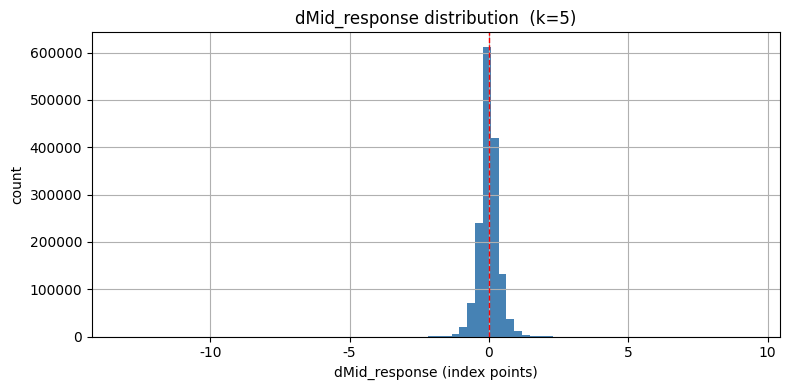

In [16]:
first_day = df_main['TradDay'].min()
s = df_main[(df_main['TradDay'] == first_day) & (df_main['session'] == 'morning')].copy()

# Recompute avg_trade for display (internal to compute_MPB, surfaced here for inspection)
s['AvgTradePrice'] = (
    (s['Turnover'].diff() / s['Volume'].diff() / 300)
    .replace([np.inf, -np.inf], np.nan)
    .ffill().bfill()
)
print("MPB — first 10 rows:")
print(s[['Volume', 'Turnover', 'MidPrice', 'AvgTradePrice', 'MPB']].head(10).to_string())
print()

assert not (df_main['MPB'] == 0).all(),                  "FAIL: MPB is all-zero"
assert not np.isinf(df_main['MPB']).any(),               "FAIL: MPB has Inf values"
first_mpb = df_main.groupby(['TradDay', 'session'])['MPB'].first()
assert first_mpb.notna().all(),                          "FAIL: MPB NaN at session start"
print("[OK] MPB assertions passed")
print(f"MPB  mean={df_main['MPB'].mean():.5f}  std={df_main['MPB'].std():.4f}")
print()

resp = df_main['dMid_response']

last_k_nan = df_main.groupby(['TradDay', 'session']).apply(lambda g: g['dMid_response'].iloc[-k:].isna().all())
assert last_k_nan.all(), "FAIL: last k rows not NaN in some session"
frac_nonzero = (resp.dropna() != 0).sum() / resp.notna().sum()
assert frac_nonzero > 0,                                 "FAIL: dMid_response is all-zero"
print("[OK] dMid_response assertions passed")
print(f"Non-zero fraction: {frac_nonzero:.2%}  (paper reports ~45%)")

fig, ax = plt.subplots(figsize=(8, 4))
resp.dropna().hist(bins=80, ax=ax, edgecolor='none', color='steelblue')
ax.axvline(0, color='red', linewidth=1, linestyle='--')
ax.set_title(f"dMid_response distribution  (k={k})")
ax.set_xlabel("dMid_response (index points)")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

## 4. Feature Matrix

### 4.1 Strategy A Feature Matrix Construction

In [17]:
# X: VOI_t0 (instantaneous) + VOI_t1 .. VOI_t{L} (lags)
# y: average of next k mid-prices minus current mid-price

L_A = 5    # number of lags -- 6 VOI columns total (t0..t5)
k_A = 20   # Strategy A forecast horizon (10 s at 500 ms intervals)


def build_feature_matrix_A(df: pd.DataFrame, L: int = L_A, k: int = k_A) -> pd.DataFrame:
    """Build Strategy A feature matrix for one (TradDay, session) slice.

    Trims L+1 leading rows and k trailing rows; returns a NaN-free DataFrame.
    TradDay / session are joined back from the original index after apply().
    """
    n   = len(df)
    voi = df['VOI']

    # Lag matrix: VOI_t0 is current; VOI_tj is shifted j steps (shift creates j leading NaNs).
    X = pd.DataFrame(
        {f'VOI_t{j}': voi.shift(j) for j in range(L + 1)},
        index=df.index,
    )

    # Response: average mid-price over next k ticks minus current mid-price.
    y = compute_response(df, k=k).rename('y')

    # Trim leading L+1 rows (shift(L)[L] = voi[0] = session-open NaN propagated through lags)
    # and trailing k rows (dMid_response is NaN for the last k ticks).
    out = pd.concat([X, y], axis=1).iloc[L + 1 : n - k]

    assert out.isna().sum().sum() == 0, \
        f"NaN after trim: {out.isna().sum()[out.isna().sum() > 0].to_dict()}"

    return out.copy()


# apply() preserves the original df_main row index; join brings back market data columns.
all_features_A = (
    df_main.groupby(['TradDay', 'session'], group_keys=False)
    .apply(build_feature_matrix_A)
    .join(df_main[['TradDay', 'session', 'BidPrice1', 'AskPrice1', 'MidPrice', 'time_seconds']])
    .reset_index(drop=True)
)

cols_joined = ['TradDay', 'session', 'BidPrice1', 'AskPrice1', 'MidPrice', 'time_seconds']
assert all_features_A[cols_joined].isna().sum().sum() == 0, "NaNs in joined columns"
n_sessions = df_main.groupby(['TradDay', 'session']).ngroups
expected_rows = len(df_main) - n_sessions * (L_A + 1 + k_A)
assert len(all_features_A) == expected_rows, f"Row count mismatch: got {len(all_features_A)}, expected {expected_rows}"

print(f"all_features_A: {all_features_A.shape}")
print(f"Columns: {list(all_features_A.columns)}")
print(f"Expected rows: {len(df_main):,} ticks - "
      f"{n_sessions} sessions x (L+1={L_A+1} + k={k_A}) = {expected_rows:,}")
print()
print("First 3 rows:")
print(all_features_A[['VOI_t0', 'y', 'TradDay', 'session', 'BidPrice1', 'time_seconds']].head(3).to_string())


all_features_A: (1556192, 13)
Columns: ['VOI_t0', 'VOI_t1', 'VOI_t2', 'VOI_t3', 'VOI_t4', 'VOI_t5', 'y', 'TradDay', 'session', 'BidPrice1', 'AskPrice1', 'MidPrice', 'time_seconds']
Expected rows: 1,559,260 ticks - 118 sessions x (L+1=6 + k=20) = 1,556,192

First 3 rows:
   VOI_t0         y   TradDay    session    BidPrice1  time_seconds
0     1.0  1.075366  20260203  afternoon  4617.399902       46803.3
1    -1.0  2.050171  20260203  afternoon  4616.600098       46803.8
2     1.0  1.489966  20260203  afternoon  4617.200195       46804.3


### 4.2 Integrity Check

In [18]:
first_day  = all_features_A['TradDay'].min()
s_feat = all_features_A[
    (all_features_A['TradDay'] == first_day) & (all_features_A['session'] == 'morning')
]
n_session = len(df_main[(df_main['TradDay'] == first_day) & (df_main['session'] == 'morning')])

print(f"Sample shape: {s_feat.shape}  "
      f"(session ticks={n_session}, expect {n_session - (L_A + 1) - k_A} rows after trim)")
print()

assert s_feat.isna().sum().sum() == 0, "FAIL: NaN found in feature matrix"
print("[OK] Zero NaN values")
print()

voi_cols = [f'VOI_t{j}' for j in range(L_A + 1)]
print("First 5 rows — VOI_t1 should equal VOI_t0 from the previous row:")
print(s_feat[voi_cols + ['y']].head(5).to_string())
print()

corr = s_feat['VOI_t0'].corr(s_feat['y'])
print(f"Corr(VOI_t0, y) = {corr:.4f}  (expect small positive ~0.05-0.15)")
print()

print("VOI column mean / std (lags should have similar scale to VOI_t0):")
print(s_feat[voi_cols].agg(['mean', 'std']).round(2).to_string())

Sample shape: (13896, 13)  (session ticks=13922, expect 13896 rows after trim)

[OK] Zero NaN values

First 5 rows — VOI_t1 should equal VOI_t0 from the previous row:
       VOI_t0  VOI_t1  VOI_t2  VOI_t3  VOI_t4  VOI_t5         y
13410     2.0    57.0     7.0     1.0     1.0     8.0 -1.744824
13411    -1.0     2.0    57.0     7.0     1.0     1.0 -0.380029
13412    -1.0    -1.0     2.0    57.0     7.0     1.0  0.149878
13413   -19.0    -1.0    -1.0     2.0    57.0     7.0  0.704761
13414    -1.0   -19.0    -1.0    -1.0     2.0    57.0  1.820166

Corr(VOI_t0, y) = 0.0940  (expect small positive ~0.05-0.15)

VOI column mean / std (lags should have similar scale to VOI_t0):
      VOI_t0  VOI_t1  VOI_t2  VOI_t3  VOI_t4  VOI_t5
mean   -0.13   -0.13   -0.13   -0.13   -0.13   -0.13
std     5.19    5.21    5.21    5.21    5.21    5.21


### 4.3 Strategy B Feature Matrix Construction

In [19]:
k_B = 5    # forecast horizon: 2.5 s -- matches dMid_response already in df_main
L_B = 5    # number of lags -- 6 VOI columns + 6 OIR columns


def build_feature_matrix_B(df: pd.DataFrame, L: int = L_B, k: int = k_B) -> pd.DataFrame:
    """Build Strategy B feature matrix for one (TradDay, session) slice.

    All features are normalised by the contemporaneous bid-ask spread
    (Shen 2015 equation 3.6). Trims L+1 leading rows and k trailing rows.
    """
    n      = len(df)
    spread = df['Spread']

    # VOI_t0..t{L} / contemporaneous Spread
    voi = df['VOI']
    X_voi = pd.DataFrame(
        {f'VOI_t{j}': voi.shift(j) / spread for j in range(L + 1)},
        index=df.index,
    )

    # OIR_t0..t{L} / contemporaneous Spread
    oir = df['OIR']
    X_oir = pd.DataFrame(
        {f'OIR_t{j}': oir.shift(j) / spread for j in range(L + 1)},
        index=df.index,
    )

    # MPB / contemporaneous Spread (scalar feature)
    X_mpb = (df['MPB'] / spread).rename('MPB_norm')

    # y: dMid_response already computed at k=5; last k rows are NaN.
    y = df['dMid_response'].rename('y')

    # Trim leading L+1 rows and trailing k rows.
    out = pd.concat([X_voi, X_oir, X_mpb, y], axis=1).iloc[L + 1 : n - k]

    assert out.isna().sum().sum() == 0, \
        f"NaN after trim: {out.isna().sum()[out.isna().sum() > 0].to_dict()}"

    return out.copy()


all_features_B = (
    df_main.groupby(['TradDay', 'session'], group_keys=False)
    .apply(build_feature_matrix_B)
    .join(df_main[['TradDay', 'session', 'BidPrice1', 'AskPrice1', 'MidPrice', 'time_seconds']])
    .reset_index(drop=True)
)

cols_joined = ['TradDay', 'session', 'BidPrice1', 'AskPrice1', 'MidPrice', 'time_seconds']
assert all_features_B[cols_joined].isna().sum().sum() == 0, "NaNs in joined columns"

n_sessions_B   = df_main.groupby(['TradDay', 'session']).ngroups
expected_rows_B = len(df_main) - n_sessions_B * (L_B + 1 + k_B)
assert len(all_features_B) == expected_rows_B, \
    f"Row count mismatch: got {len(all_features_B)}, expected {expected_rows_B}"

print(f"all_features_B: {all_features_B.shape}")
print(f"Columns: {list(all_features_B.columns)}")
print(f"Expected rows: {len(df_main):,} ticks - "
      f"{n_sessions_B} sessions x (L+1={L_B+1} + k={k_B}) = {expected_rows_B:,}")
print()
print("First 3 rows:")
print(all_features_B[['VOI_t0', 'OIR_t0', 'MPB_norm', 'y', 'TradDay', 'session']].head(3).to_string())


all_features_B: (1557962, 20)
Columns: ['VOI_t0', 'VOI_t1', 'VOI_t2', 'VOI_t3', 'VOI_t4', 'VOI_t5', 'OIR_t0', 'OIR_t1', 'OIR_t2', 'OIR_t3', 'OIR_t4', 'OIR_t5', 'MPB_norm', 'y', 'TradDay', 'session', 'BidPrice1', 'AskPrice1', 'MidPrice', 'time_seconds']
Expected rows: 1,559,260 ticks - 118 sessions x (L+1=6 + k=5) = 1,557,962

First 3 rows:
     VOI_t0    OIR_t0  MPB_norm         y   TradDay    session
0  2.500611 -0.833537 -0.405617 -0.239648  20260203  afternoon
1 -2.500611  0.000000  1.209361  0.780176  20260203  afternoon
2  1.667752 -0.833876 -0.280323  0.200000  20260203  afternoon


## 5. Strategy A Backtest (Shen 2015)

### 5.1 Constants

In [20]:
cols_needed = ['BidPrice1', 'AskPrice1', 'MidPrice', 'time_seconds']

# all_features_A already contains the needed columns; no re-join required.
features_full = all_features_A

assert features_full[cols_needed].isna().sum().sum() == 0, "NaNs in market data columns"

print(f"features_full shape: {features_full.shape}")
print(features_full.head(2))

FEATURE_COLS        = ['VOI_t0', 'VOI_t1', 'VOI_t2', 'VOI_t3', 'VOI_t4', 'VOI_t5']
TARGET_COL          = 'y'             # 20-step average mid-price change (k=20)
DAY_COL             = 'TradDay'
SESSION_COL         = 'session'
BID_COL             = 'BidPrice1'
ASK_COL             = 'AskPrice1'
TIME_COL            = 'time_seconds'

CONTRACT_MULT       = 300             # 300 CNY per index point

# Shen (2015) paper era (~2014): both legs 2.5e-5
# Current CFFEX IF (since 2023): open 2.3e-5, same-day close 2.3e-4
TR_COST_PAPER = 2.5e-5
TR_COST_OPEN  = 2.3e-5
TR_COST_CLOSE = 2.3e-4
TR_COST_ZERO  = 0.0

# Trading hours; see Section 2.2 above.
TRADING_HOURS = {
    'morning': {
        'open':  9 * 3600 + 16 * 60,    # 09:16 -> trading opens
        'close': 11 * 3600 + 20 * 60,   # 11:20 -> no new opens after this
        'end':   11 * 3600 + 28 * 60,   # 11:28 -> force-close all positions
    },
    'afternoon': {
        'open':  13 * 3600 + 1 * 60,    # 13:01 -> trading opens
        'close': 15 * 3600 + 0 * 60,    # 15:00 -> no new opens after this
        'end':   15 * 3600 + 13 * 60,   # 15:13 -> force-close all positions
    },
}

# Walk-forward uses all trading days; run_backtest internally skips day 1 (no prior training day).
ALL_DAYS = sorted(features_full[DAY_COL].unique().tolist())
print(f"Total trading days: {len(ALL_DAYS)}  |  First: {ALL_DAYS[0]}  |  Last: {ALL_DAYS[-1]}")


features_full shape: (1556192, 13)
   VOI_t0  VOI_t1  VOI_t2  VOI_t3  VOI_t4  VOI_t5         y   TradDay  \
0     1.0     7.0     2.0     1.0    20.0     2.0  1.075366  20260203   
1    -1.0     1.0     7.0     2.0     1.0    20.0  2.050171  20260203   

     session    BidPrice1    AskPrice1     MidPrice  time_seconds  
0  afternoon  4617.399902  4617.799805  4617.599609       46803.3  
1  afternoon  4616.600098  4617.000000  4616.799805       46803.8  
Total trading days: 59  |  First: 20260203  |  Last: 20260508


### 5.2 Baseline Backtest & Parameter Confirmation

In [21]:
results_paper = run_backtest(
    features_df=features_full,
    feature_cols=FEATURE_COLS,
    target_col=TARGET_COL,
    day_col=DAY_COL,
    session_col=SESSION_COL,
    bid_col=BID_COL,
    ask_col=ASK_COL,
    time_col=TIME_COL,
    threshold=0.2,
    tr_cost_open=TR_COST_PAPER, tr_cost_close=TR_COST_PAPER,
    contract_multiplier=CONTRACT_MULT,
    trading_hours=TRADING_HOURS,
)

### 5.3 Performance Metrics (Current Market Cost)

In [22]:
metrics_paper = compute_performance_metrics(
    results_paper, trading_days=ALL_DAYS, output_dir='results/', label='A_paper')

Performance Summary
  Trading days              : 58
  Total round-trips         : 8937
  Mean daily PnL (CNY)      :   -10,300.22
  Std daily PnL             :    23,677.66
  Standard error            :     3,109.03
  t-statistic               :      -3.3130
  p-value (one-tailed)      :     9.99e-01
  Days with profit          :    15 / 58  (25.9%)
  Days with loss            :    43 / 58  (74.1%)
  Mean daily trade volume   :       154.09
  Avg daily Sharpe          :      -0.0734
  Annualized Sharpe         :      -6.9057
  Avg R-squared (training)  :       0.0112
  Win rate per trade        :       34.75%
  Max drawdown (CNY)        :   599,832.94


### 5.4 Zero-Cost Backtest

In [23]:
results_current = run_backtest(
    features_df=features_full,
    feature_cols=FEATURE_COLS,
    target_col=TARGET_COL,
    day_col=DAY_COL,
    session_col=SESSION_COL,
    bid_col=BID_COL,
    ask_col=ASK_COL,
    time_col=TIME_COL,
    threshold=0.2,
    tr_cost_open=TR_COST_OPEN, tr_cost_close=TR_COST_CLOSE,
    contract_multiplier=CONTRACT_MULT,
    trading_hours=TRADING_HOURS,
)
metrics_current = compute_performance_metrics(
    results_current, trading_days=ALL_DAYS, output_dir='results/', verbose=False, label='A_current')

In [24]:
results_zero = run_backtest(
    features_df=features_full,
    feature_cols=FEATURE_COLS,
    target_col=TARGET_COL,
    day_col=DAY_COL,
    session_col=SESSION_COL,
    bid_col=BID_COL,
    ask_col=ASK_COL,
    time_col=TIME_COL,
    threshold=0.2,
    tr_cost_open=TR_COST_ZERO, tr_cost_close=TR_COST_ZERO,
    contract_multiplier=CONTRACT_MULT,
    trading_hours=TRADING_HOURS,
)
metrics_zero = compute_performance_metrics(
    results_zero, trading_days=ALL_DAYS, output_dir='results/', verbose=False, label='A_zero')

### 5.5 Two-Scenario Comparison

In [25]:
comparison_A = pd.DataFrame({
    'Paper cost (2.5e-5)':                       metrics_paper,
    'Current cost (open=2.3e-5, close=2.3e-4)': metrics_current,
    'Zero cost':                                 metrics_zero,
}).T

display(comparison_A)

,mean_daily_pnl,std_daily_pnl,stderr_daily_pnl,t_stat,p_value,days_with_profit,days_with_loss,mean_daily_trade_volume,avg_daily_sharpe,annualized_sharpe,avg_r_squared,win_rate_per_trade,max_drawdown,n_days,n_trades
Paper cost (2.5e-5),-10300.217773,23677.656250,3109.028581,-3.313002,0.999196,15.0,43.0,154.086207,-0.073433,-6.905704,0.011194,0.347544,5.998329e+05,58.0,8937.0
"Current cost (open=2.3e-5, close=2.3e-4)",-53121.101562,65025.812500,8538.307483,-6.221502,1.000000,1.0,57.0,154.086207,-0.364853,-12.968255,0.011194,0.237328,3.039790e+06,58.0,8937.0
Zero cost,246.773041,17554.367188,2305.001337,0.107060,0.457559,30.0,28.0,154.086207,-0.001656,0.223158,0.011194,0.383350,9.857490e+04,58.0,8937.0


### 5.6 Parameter Sweep & Optimal q

In [26]:
sweep_df = run_parameter_sweep(
    features_df=features_full,
    feature_cols=FEATURE_COLS,
    target_col=TARGET_COL,
    day_col=DAY_COL,
    session_col=SESSION_COL,
    bid_col=BID_COL,
    ask_col=ASK_COL,
    time_col=TIME_COL,
    q_values=[round(0.13 + i * 0.005, 3) for i in range(15)],  # 0.13 to 0.20
    tr_cost_open=TR_COST_PAPER, tr_cost_close=TR_COST_PAPER,
    contract_multiplier=CONTRACT_MULT,
    trading_hours=TRADING_HOURS,
    trading_days=ALL_DAYS,
)

display(sweep_df)

Precomputing signals for parameter sweep...
Signals cached for 116 (day, session) pairs.
  q=0.130  mean_daily_pnl=   -35,868  t=-6.749  sharpe=-14.067
  q=0.135  mean_daily_pnl=   -32,251  t=-6.243  sharpe=-13.014
  q=0.140  mean_daily_pnl=   -27,854  t=-5.525  sharpe=-11.516
  q=0.145  mean_daily_pnl=   -25,609  t=-5.391  sharpe=-11.236
  q=0.150  mean_daily_pnl=   -23,693  t=-5.284  sharpe=-11.014
  q=0.155  mean_daily_pnl=   -22,042  t=-5.187  sharpe=-10.813
  q=0.160  mean_daily_pnl=   -19,880  t=-4.931  sharpe=-10.279
  q=0.165  mean_daily_pnl=   -18,458  t=-4.702  sharpe=-9.802
  q=0.170  mean_daily_pnl=   -16,451  t=-4.378  sharpe=-9.127
  q=0.175  mean_daily_pnl=   -15,316  t=-4.401  sharpe=-9.174
  q=0.180  mean_daily_pnl=   -14,175  t=-4.133  sharpe=-8.614
  q=0.185  mean_daily_pnl=   -13,012  t=-3.800  sharpe=-7.920
  q=0.190  mean_daily_pnl=   -11,731  t=-3.604  sharpe=-7.512
  q=0.195  mean_daily_pnl=   -10,405  t=-3.166  sharpe=-6.599
  q=0.200  mean_daily_pnl=   -10,300

,q,mean_daily_pnl,stderr,t_stat,p_value,annualized_sharpe,avg_daily_sharpe,win_rate_per_trade,mean_daily_volume,days_with_profit,days_with_loss
0,0.130,-35867.898438,5314.790977,-6.748694,1.000000,-14.067147,-0.158838,0.304851,398.103448,4,54
1,0.135,-32251.021484,5165.569423,-6.243459,1.000000,-13.014022,-0.146684,0.308219,367.517241,5,53
2,0.140,-27853.523438,5041.411497,-5.524945,1.000000,-11.516334,-0.132666,0.314761,339.775862,6,52
3,0.145,-25609.238281,4750.775992,-5.390538,0.999999,-11.236172,-0.126467,0.318487,315.500000,7,51
4,0.150,-23692.574219,4483.882331,-5.283942,0.999999,-11.013981,-0.123834,0.321740,292.482759,8,50
5,0.155,-22041.966797,4249.215168,-5.187303,0.999999,-10.812544,-0.120743,0.324606,273.275862,11,47
6,0.160,-19880.107422,4031.271878,-4.931472,0.999996,-10.279285,-0.110385,0.327477,254.189655,14,44
7,0.165,-18458.382812,3925.352724,-4.702350,0.999992,-9.801696,-0.109609,0.330989,237.793103,12,46
8,0.170,-16450.693359,3757.166879,-4.378483,0.999974,-9.126621,-0.103462,0.335222,222.189655,16,42
9,0.175,-15315.579102,3479.951045,-4.401090,0.999976,-9.173743,-0.106992,0.336600,207.603448,14,44


### 5.7 Signal Distribution Diagnostics

EFPC signal distribution  (each day trained on prev day OLS)

  Days analyzed       : 58
  Signal mean (avg)   : 0.0015
  Signal std  (avg)   : 0.0646

  |EFPC| percentiles (averaged across days):
    p50 : 0.0280  index points
    p90 : 0.0879  index points
    p95 : 0.1196  index points
    p99 : 0.2211  index points

  Implied trigger rate to get 145.9 trades/day
    (~26360 ticks/day)  =>  0.55%

   q (abs)   |EFPC| pctile   trigger rate
  --------  --------------  -------------
      0.10           91.7%           8.3%
      0.13           95.0%           5.0%
      0.15           96.3%           3.7%
      0.20           98.1%           1.9%
      0.30           99.3%           0.7%
      0.50           99.8%           0.2%

  Verdict:
    q=0.20 is the 98.1th percentile of |EFPC|
    => 1.9% of ticks exceed it
    HIGH threshold: only tail signals fire (consistent with quantile framing)


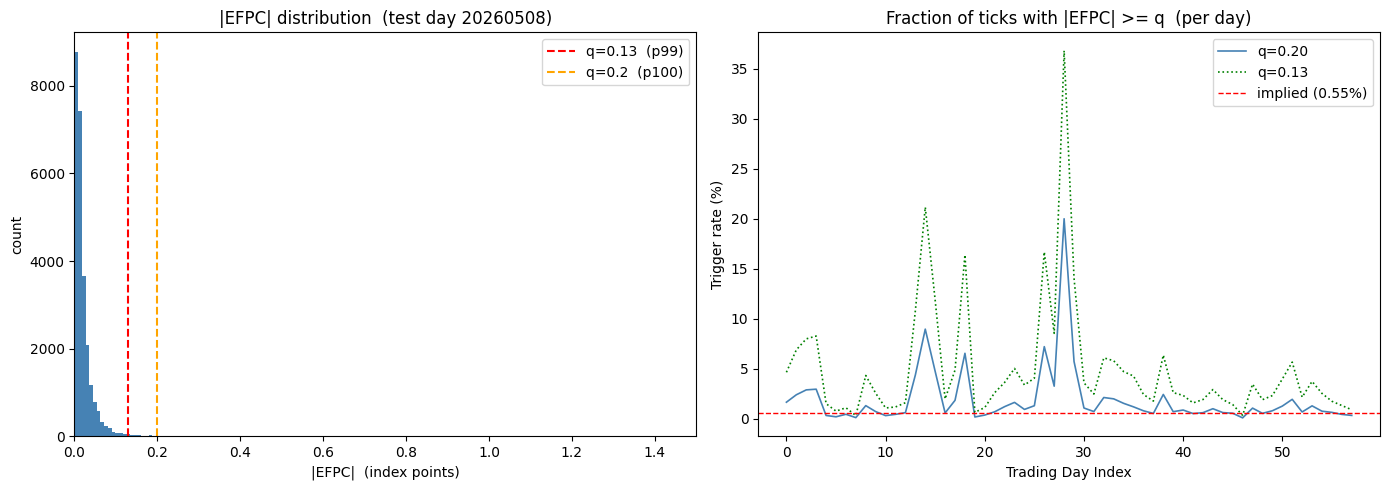

In [27]:
Q_GRID = [0.10, 0.13, 0.15, 0.20, 0.30, 0.50]

sorted_days = sorted(features_full[DAY_COL].unique())
diag = signal_diagnostics(features_full, FEATURE_COLS, sorted_days, Q_GRID)
avg_ticks       = diag['n_ticks'].mean()
implied_trigger = 145.92 / avg_ticks   # fraction of ticks needed to yield 145.9 trades/day

print("=" * 62)
print("EFPC signal distribution  (each day trained on prev day OLS)")
print("=" * 62)
print(f"\n  Days analyzed       : {len(diag)}")
print(f"  Signal mean (avg)   : {diag['sig_mean'].mean():.4f}")
print(f"  Signal std  (avg)   : {diag['sig_std'].mean():.4f}")
print()
print("  |EFPC| percentiles (averaged across days):")
print(f"    p50 : {diag['sig_p50'].mean():.4f}  index points")
print(f"    p90 : {diag['sig_p90'].mean():.4f}  index points")
print(f"    p95 : {diag['sig_p95'].mean():.4f}  index points")
print(f"    p99 : {diag['sig_p99'].mean():.4f}  index points")
print()
print(f"  Implied trigger rate to get 145.9 trades/day")
print(f"    (~{avg_ticks:.0f} ticks/day)  =>  {implied_trigger*100:.2f}%")
print()
print(f"  {'q (abs)':>8}  {'|EFPC| pctile':>14}  {'trigger rate':>13}")
print(f"  {'-'*8}  {'-'*14}  {'-'*13}")
for qv in Q_GRID:
    p  = diag[f'pctile_{qv}'].mean() * 100
    tr = diag[f'trigger_{qv}'].mean() * 100
    print(f"  {qv:>8.2f}  {p:>13.1f}%  {tr:>12.1f}%")

print()
print("  Verdict:")
q020_pctile  = diag['pctile_0.2'].mean() * 100
q020_trigger = diag['trigger_0.2'].mean() * 100
print(f"    q=0.20 is the {q020_pctile:.1f}th percentile of |EFPC|")
print(f"    => {q020_trigger:.1f}% of ticks exceed it")
if q020_pctile > 80:
    print("    HIGH threshold: only tail signals fire (consistent with quantile framing)")
elif q020_pctile < 50:
    print("    LOW threshold: majority of ticks exceed it -- too many trades, costs dominate")
else:
    print("    MID threshold: moderate trigger rate")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: |EFPC| histogram for the most recent trading day.
last_day  = sorted_days[-1]
prev_last = sorted_days[-2]
tr_df  = features_full[features_full[DAY_COL] == prev_last]
c_last = fit_ols_model(tr_df[FEATURE_COLS].values, tr_df[TARGET_COL].values)
te_df  = features_full[features_full[DAY_COL] == last_day]
sigs   = np.abs(compute_signals(te_df[FEATURE_COLS].values, c_last))

ax = axes[0]
ax.hist(sigs, bins=120, color='steelblue', edgecolor='none')
for qv, col in [(0.13, 'red'), (0.20, 'orange')]:
    pct = float(np.mean(sigs < qv)) * 100
    ax.axvline(qv, color=col, linewidth=1.5, linestyle='--',
               label=f'q={qv}  (p{pct:.0f})')
ax.set_xlabel('|EFPC|  (index points)')
ax.set_ylabel('count')
ax.set_title(f'|EFPC| distribution  (test day {last_day})')
ax.set_xlim(0, max(1.5, float(np.percentile(sigs, 99)) * 1.1))
ax.legend()

# Right: trigger rate over time.
ax2 = axes[1]
ax2.plot(range(len(diag)), diag['trigger_0.2'] * 100,
         color='steelblue', linewidth=1.2, label='q=0.20')
ax2.plot(range(len(diag)), diag['trigger_0.13'] * 100,
         color='green', linewidth=1.2, linestyle=':', label='q=0.13')
ax2.axhline(implied_trigger * 100, color='red', linewidth=1, linestyle='--',
            label=f'implied ({implied_trigger*100:.2f}%)')
ax2.set_xlabel('Trading Day Index')
ax2.set_ylabel('Trigger rate (%)')
ax2.set_title('Fraction of ticks with |EFPC| >= q  (per day)')
ax2.legend()

plt.tight_layout()
plt.show()


### 5.8 Signal Stability Over Time

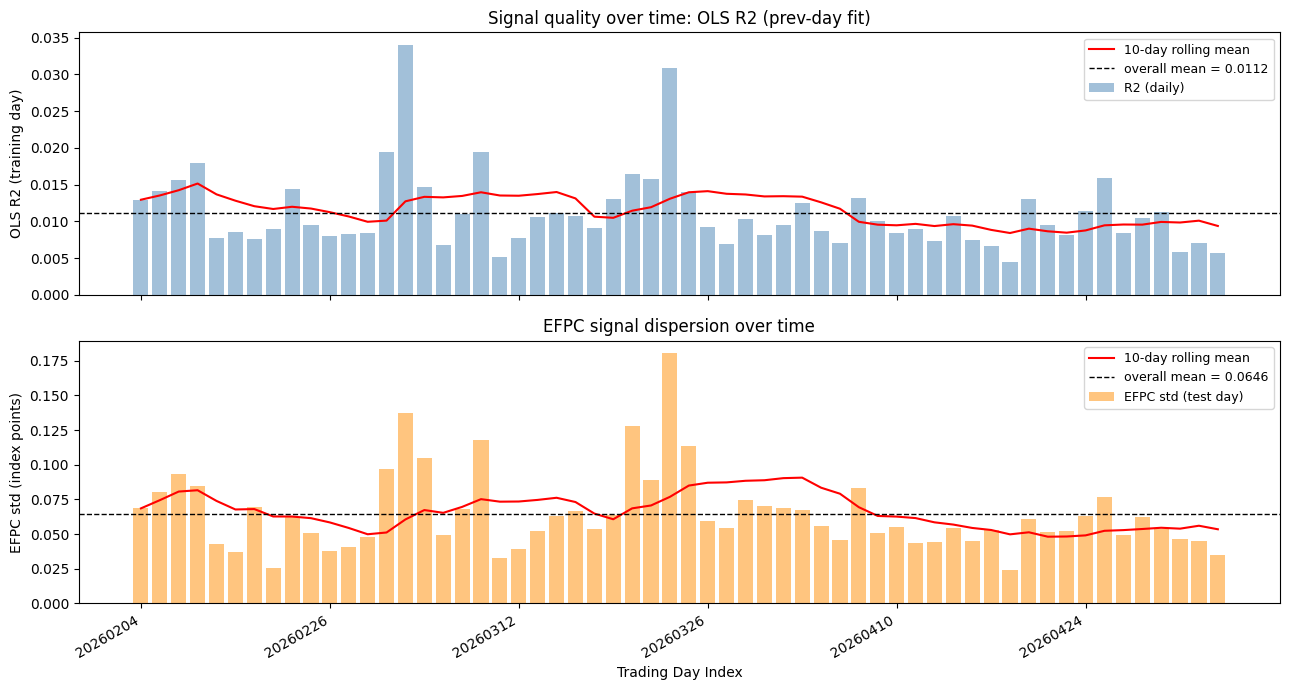

R2  first 29 days : 0.0131
R2  last  29 days : 0.0093
sig_std  first 29 days : 0.0719
sig_std  last  29 days : 0.0572


In [28]:
r2_list = []
for i, day in enumerate(sorted_days):
    if i == 0:
        continue
    prev_day = sorted_days[i - 1]
    train_df = features_full[features_full[DAY_COL] == prev_day]
    X_tr = train_df[FEATURE_COLS].values
    y_tr = train_df[TARGET_COL].values
    coefs = fit_ols_model(X_tr, y_tr)
    if coefs is None:
        continue
    X_aug  = np.column_stack([np.ones(len(X_tr)), X_tr])
    y_pred = X_aug @ coefs
    ss_res = np.sum((y_tr - y_pred) ** 2)
    ss_tot = np.sum((y_tr - y_tr.mean()) ** 2)
    r2_list.append({'TradDay': day, 'r2': float(1 - ss_res / ss_tot) if ss_tot > 0 else 0.0})

r2_df = pd.DataFrame(r2_list).merge(diag[['TradDay', 'sig_std']], on='TradDay')

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

ax1 = axes[0]
ax1.bar(range(len(r2_df)), r2_df['r2'], color='steelblue', alpha=0.5, label='R2 (daily)')
roll_r2 = r2_df['r2'].rolling(10, min_periods=1).mean()
ax1.plot(range(len(r2_df)), roll_r2, color='red', linewidth=1.5, label='10-day rolling mean')
ax1.axhline(r2_df['r2'].mean(), color='black', linewidth=1, linestyle='--',
            label=f'overall mean = {r2_df["r2"].mean():.4f}')
ax1.set_ylabel('OLS R2 (training day)')
ax1.set_title('Signal quality over time: OLS R2 (prev-day fit)')
ax1.legend(fontsize=9)
ax1.set_ylim(bottom=0)

ax2 = axes[1]
ax2.bar(range(len(r2_df)), r2_df['sig_std'], color='darkorange', alpha=0.5, label='EFPC std (test day)')
roll_std = r2_df['sig_std'].rolling(10, min_periods=1).mean()
ax2.plot(range(len(r2_df)), roll_std, color='red', linewidth=1.5, label='10-day rolling mean')
ax2.axhline(r2_df['sig_std'].mean(), color='black', linewidth=1, linestyle='--',
            label=f'overall mean = {r2_df["sig_std"].mean():.4f}')
ax2.set_ylabel('EFPC std (index points)')
ax2.set_xlabel('Trading Day Index')
ax2.set_title('EFPC signal dispersion over time')
ax2.legend(fontsize=9)

tick_idx = list(range(0, len(r2_df), 10))
axes[1].set_xticks(tick_idx)
axes[1].set_xticklabels([str(r2_df['TradDay'].iloc[j]) for j in tick_idx], rotation=30, ha='right')

plt.tight_layout()
plt.show()

mid = len(r2_df) // 2
print(f"R2  first {mid} days : {r2_df['r2'].iloc[:mid].mean():.4f}")
print(f"R2  last  {mid} days : {r2_df['r2'].iloc[mid:].mean():.4f}")
print(f"sig_std  first {mid} days : {r2_df['sig_std'].iloc[:mid].mean():.4f}")
print(f"sig_std  last  {mid} days : {r2_df['sig_std'].iloc[mid:].mean():.4f}")

### 5.9 Volume Validation

IF main-contract daily volume  (2026-02 to 2026-05, current data)
  Trading days : 59
  Mean         :     59,747  lots/day
  Median       :     57,102  lots/day
  Min          :     37,735  lots/day
  Max          :    107,068  lots/day

Historical reference  (Shen 2015, paper period ~2014)
  2014 mean (ref)    : ~   200,000  lots/day
  2014-15 peak       : ~   400,000  lots/day
  Post-2015 restrict : ~    20,000  lots/day

  Current mean / paper-era mean = 29.9%
  Current mean / paper-era peak = 14.9%

  Per-contract notional (approx) : 1,380,000 CNY
  Current avg daily turnover     : 824.5 B CNY/day
  Paper-era avg daily turnover   : 2760.0 B CNY/day


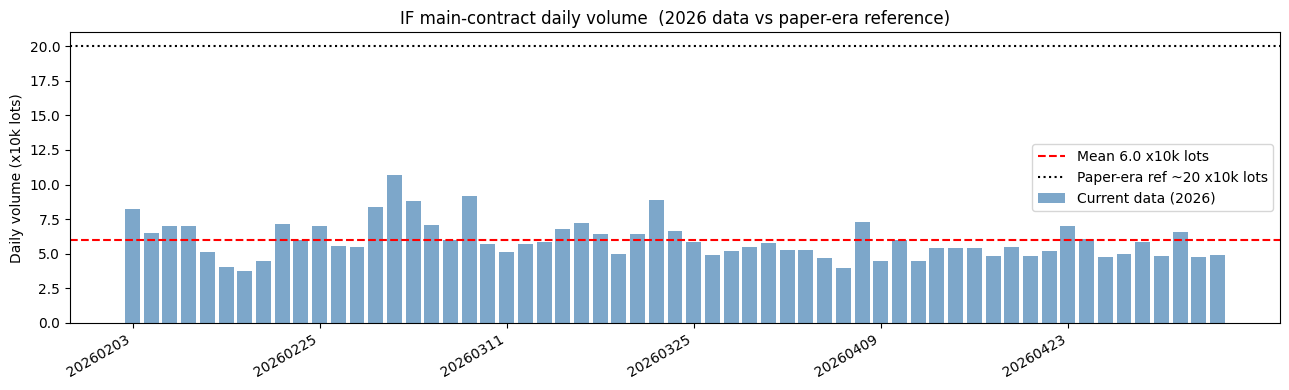

In [29]:
# CTP Volume field is cumulative within the day; take the per-day max as total daily volume.
daily_vol = df_main.groupby('TradDay')['Volume'].max().reset_index()
daily_vol.columns = ['TradDay', 'volume_lots']

# CTP Volume unit is lots (1 lot = 1 futures contract).
mean_vol   = daily_vol['volume_lots'].mean()
median_vol = daily_vol['volume_lots'].median()
min_vol    = daily_vol['volume_lots'].min()
max_vol    = daily_vol['volume_lots'].max()

print("=" * 58)
print("IF main-contract daily volume  (2026-02 to 2026-05, current data)")
print("=" * 58)
print(f"  Trading days : {len(daily_vol)}")
print(f"  Mean         : {mean_vol:>10,.0f}  lots/day")
print(f"  Median       : {median_vol:>10,.0f}  lots/day")
print(f"  Min          : {min_vol:>10,.0f}  lots/day")
print(f"  Max          : {max_vol:>10,.0f}  lots/day")
print()

# Historical reference (IF futures ~2014; source: CFFEX annual report / Wind)
paper_vol_mean = 200000   # ~200,000 lots/day (2014 annual average)
paper_vol_peak = 400000   # peak >400,000 lots (2014-11 to 2015-05 bull run)
post2015_vol   = 20000    # dropped to ~10,000-30,000 lots/day after Sep 2015 restrictions

print("=" * 58)
print("Historical reference  (Shen 2015, paper period ~2014)")
print("=" * 58)
print(f"  2014 mean (ref)    : ~{paper_vol_mean:>10,}  lots/day")
print(f"  2014-15 peak       : ~{paper_vol_peak:>10,}  lots/day")
print(f"  Post-2015 restrict : ~{post2015_vol:>10,}  lots/day")
print()
print(f"  Current mean / paper-era mean = {mean_vol/paper_vol_mean:.1%}")
print(f"  Current mean / paper-era peak = {mean_vol/paper_vol_peak:.1%}")
print()

# IF contract notional ~= 300 * index ~= 4600 * 300
contract_value = 4600 * 300
print(f"  Per-contract notional (approx) : {contract_value:,} CNY")
print(f"  Current avg daily turnover     : {mean_vol * contract_value / 1e8:.1f} B CNY/day")
print(f"  Paper-era avg daily turnover   : {paper_vol_mean * contract_value / 1e8:.1f} B CNY/day")

# Daily volume time series
fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(range(len(daily_vol)), daily_vol['volume_lots'] / 1e4,
       color='steelblue', alpha=0.7, label='Current data (2026)')
ax.axhline(mean_vol / 1e4, color='red', linewidth=1.5, linestyle='--',
           label=f'Mean {mean_vol/1e4:.1f} x10k lots')
ax.axhline(paper_vol_mean / 1e4, color='black', linewidth=1.5, linestyle=':',
           label=f'Paper-era ref ~{paper_vol_mean/1e4:.0f} x10k lots')

tick_idx = list(range(0, len(daily_vol), 10))
ax.set_xticks(tick_idx)
ax.set_xticklabels([str(daily_vol['TradDay'].iloc[j]) for j in tick_idx],
                   rotation=30, ha='right')
ax.set_ylabel('Daily volume (x10k lots)')
ax.set_title('IF main-contract daily volume  (2026 data vs paper-era reference)')
ax.legend()
plt.tight_layout()
plt.show()


### 5.10 Summary Plot

In [30]:
plot_results(results_paper, sweep_df=sweep_df, output_dir='results/', label='A_paper')
print("All outputs saved to results/")

Plots saved to results/
All outputs saved to results/


## 6. Strategy B Backtest (Enhanced Model)

### 6.1 Constants

In [31]:
FEATURE_COLS_B = (
    [f'VOI_t{j}' for j in range(L_B + 1)] +
    [f'OIR_t{j}' for j in range(L_B + 1)] +
    ['MPB_norm']
)

assert len(FEATURE_COLS_B) == 13, f"Expected 13 features, got {len(FEATURE_COLS_B)}"
print(f"Strategy B feature columns ({len(FEATURE_COLS_B)}): {FEATURE_COLS_B}")

Strategy B feature columns (13): ['VOI_t0', 'VOI_t1', 'VOI_t2', 'VOI_t3', 'VOI_t4', 'VOI_t5', 'OIR_t0', 'OIR_t1', 'OIR_t2', 'OIR_t3', 'OIR_t4', 'OIR_t5', 'MPB_norm']


### 6.2 Baseline Backtest & Parameter Confirmation

In [32]:
_bt_kwargs_B = dict(
    features_df=all_features_B,
    feature_cols=FEATURE_COLS_B,
    target_col=TARGET_COL,
    day_col=DAY_COL,
    session_col=SESSION_COL,
    bid_col=BID_COL,
    ask_col=ASK_COL,
    time_col=TIME_COL,
    threshold=0.2,
    contract_multiplier=CONTRACT_MULT,
    trading_hours=TRADING_HOURS,
)

results_B_paper   = run_backtest(**_bt_kwargs_B, tr_cost_open=TR_COST_PAPER, tr_cost_close=TR_COST_PAPER)
results_B_current = run_backtest(**_bt_kwargs_B, tr_cost_open=TR_COST_OPEN,  tr_cost_close=TR_COST_CLOSE)
results_B_zero    = run_backtest(**_bt_kwargs_B, tr_cost_open=TR_COST_ZERO,  tr_cost_close=TR_COST_ZERO)

metrics_B_paper   = compute_performance_metrics(results_B_paper,   trading_days=ALL_DAYS, output_dir='results/', verbose=False, label='B_paper')
metrics_B_current = compute_performance_metrics(results_B_current, trading_days=ALL_DAYS, output_dir='results/', verbose=False, label='B_current')
metrics_B_zero    = compute_performance_metrics(results_B_zero,    trading_days=ALL_DAYS, output_dir='results/', verbose=False, label='B_zero')

In [33]:
# Train on ALL_DAYS[0], test on ALL_DAYS[1]

train_day = ALL_DAYS[0]
test_day  = ALL_DAYS[1]

train_B = all_features_B[all_features_B[DAY_COL] == train_day]
coefs_B = fit_ols_model(train_B[FEATURE_COLS_B].values, train_B[TARGET_COL].values)

# Expected signs from Shen (2015) Table 3.1
EXPECTED = {
    'VOI_t0':  '+',  'VOI_t1':  '+',
    'VOI_t2': '~0',  'VOI_t3': '~0',  'VOI_t4': '~0',  'VOI_t5': '~0',
    'OIR_t0':  '+',  'OIR_t1':  '-',
    'OIR_t2': '~0',  'OIR_t3': '~0',  'OIR_t4': '~0',  'OIR_t5': '~0',
    'MPB_norm': '+',
}

print(f'Strategy B  OLS coefficients  (train={train_day})')
print('=' * 58)
print(f"  {'Feature':>12}  {'Coef':>10}  {'Expected':>8}  Flag")
print(f"  {'-'*12}  {'-'*10}  {'-'*8}  ----")
print(f"  {'intercept':>12}  {coefs_B[0]:>10.5f}")
for j, feat in enumerate(FEATURE_COLS_B):
    coef   = coefs_B[j + 1]
    exp    = EXPECTED[feat]
    actual = '+' if coef > 0 else '-'
    wrong  = (exp != '~0') and (actual != exp)
    flag   = '  *** WRONG' if wrong else ''
    print(f"  {feat:>12}  {coef:>10.5f}  {exp:>8}{flag}")

test_B  = all_features_B[all_features_B[DAY_COL] == test_day]
sigs_B  = compute_signals(test_B[FEATURE_COLS_B].values, coefs_B)

train_A = features_full[features_full[DAY_COL] == train_day]
coefs_A = fit_ols_model(train_A[FEATURE_COLS].values, train_A[TARGET_COL].values)
test_A  = features_full[features_full[DAY_COL] == test_day]
sigs_A  = compute_signals(test_A[FEATURE_COLS].values, coefs_A)

print()
print(f'Signal distribution  (test={test_day})')
print('=' * 58)
print(f"  {'Metric':>8}  {'Strategy B':>12}  {'Strategy A':>12}")
print(f"  {'-'*8}  {'-'*12}  {'-'*12}")
for label, fn in [
    ('mean',   lambda s: np.mean(s)),
    ('std',    lambda s: np.std(s)),
    ('|s|p50', lambda s: np.percentile(np.abs(s), 50)),
    ('|s|p95', lambda s: np.percentile(np.abs(s), 95)),
]:
    print(f"  {label:>8}  {fn(sigs_B):>12.5f}  {fn(sigs_A):>12.5f}")


Strategy B  OLS coefficients  (train=20260203)
       Feature        Coef  Expected  Flag
  ------------  ----------  --------  ----
     intercept     0.00142
        VOI_t0     0.00191         +
        VOI_t1     0.00211         +
        VOI_t2     0.00058        ~0
        VOI_t3    -0.00014        ~0
        VOI_t4    -0.00014        ~0
        VOI_t5     0.00016        ~0
        OIR_t0     0.02853         +
        OIR_t1    -0.01927         -
        OIR_t2     0.00065        ~0
        OIR_t3     0.00371        ~0
        OIR_t4     0.00219        ~0
        OIR_t5    -0.00345        ~0
      MPB_norm     0.09720         +

Signal distribution  (test=20260204)
    Metric    Strategy B    Strategy A
  --------  ------------  ------------
      mean       0.00319       0.00447
       std       0.08010       0.06856
    |s|p50       0.04002       0.02754
    |s|p95       0.16459       0.12639


## 7. Strategy A vs Strategy B Comparison

In [34]:
KEY_METRICS = ['mean_daily_pnl', 'win_rate_per_trade', 'annualized_sharpe',
               'n_trades', 'mean_daily_trade_volume', 'max_drawdown']

ab_comparison = pd.DataFrame({
    'A  Paper (2.5e-5)':                       {k: metrics_paper[k]     for k in KEY_METRICS},
    'A  Current (open=2.3e-5, close=2.3e-4)': {k: metrics_current[k]   for k in KEY_METRICS},
    'A  Zero cost':                            {k: metrics_zero[k]      for k in KEY_METRICS},
    'B  Paper (2.5e-5)':                       {k: metrics_B_paper[k]   for k in KEY_METRICS},
    'B  Current (open=2.3e-5, close=2.3e-4)': {k: metrics_B_current[k] for k in KEY_METRICS},
    'B  Zero cost':                            {k: metrics_B_zero[k]    for k in KEY_METRICS},
}).T

ab_comparison.index.name = 'Scenario'


## 8. Strategy B Parameter Sweep *(In-Sample)*

> **Note**: All results in Sections 8, 9, and 10 are computed on the **full 2026 dataset** with no held-out period. They represent an in-sample upper bound and should be read as a theoretical ceiling, not an estimate of live returns. The pre-specified threshold (q = 0.20, k = 5) used in Sections 5–6 is not subject to this bias. Out-of-sample robustness is evaluated in Sections 12 (train/test split) and 13 (WFO).

### 8.1 Signal Distribution Diagnostics

Strategy B  |signal| distribution  (prev-day OLS)
  Days   : 58
  Signal std (avg): 0.07421  index pts

  |signal| percentiles (avg across days):
    p50 : 0.03571
    p90 : 0.11176
    p95 : 0.15058
    p99 : 0.24942

        q    trigger%    trades/day
  -------  ----------  ------------
    0.005      91.87%        24259
    0.010      83.89%        22152
    0.020      69.01%        18223
    0.030      55.89%        14758
    0.050      35.88%         9473
    0.080      18.62%         4916
    0.100      12.52%         3305
    0.150       5.11%         1349
    0.200       2.30%          606
    0.300       0.59%          156
    0.500       0.10%           25

  Ref: Strategy A q=0.20 -> ~146 trades/day (0.55% of ticks)


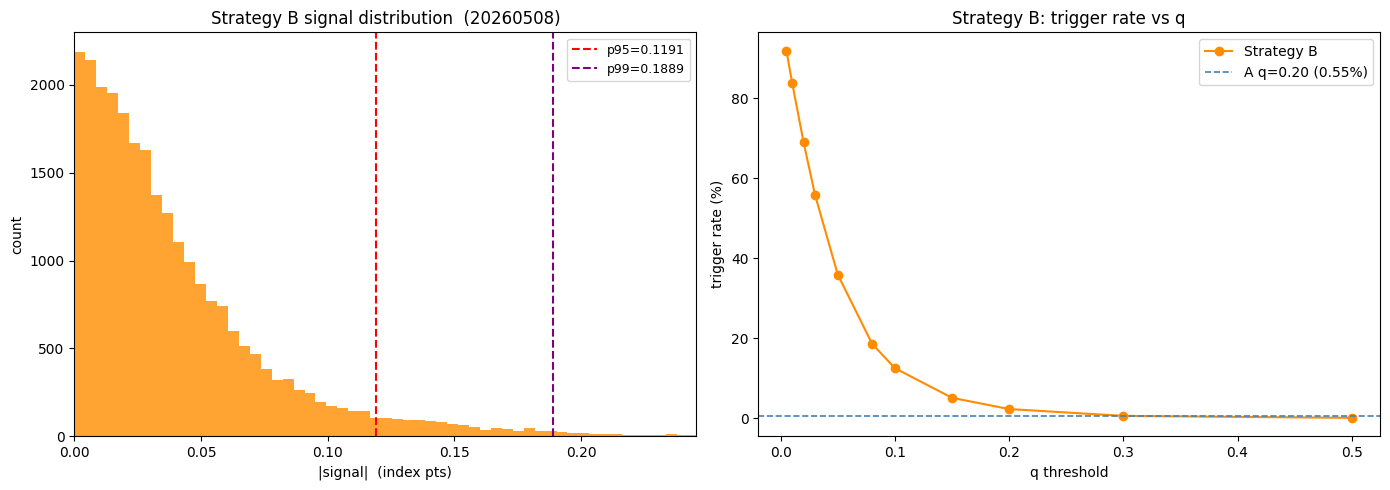

In [35]:
Q_DIAG = [0.005, 0.01, 0.02, 0.03, 0.05, 0.08, 0.10, 0.15, 0.20, 0.30, 0.50]

sorted_days_B = sorted(all_features_B[DAY_COL].unique())
diag_B = signal_diagnostics(all_features_B, FEATURE_COLS_B, sorted_days_B, Q_DIAG)
avg_ticks_B = all_features_B.groupby(DAY_COL).size().mean()

print('=' * 62)
print('Strategy B  |signal| distribution  (prev-day OLS)')
print('=' * 62)
print(f'  Days   : {len(diag_B)}')
print(f'  Signal std (avg): {diag_B["sig_std"].mean():.5f}  index pts')
print()
print('  |signal| percentiles (avg across days):')
for label, col in [("p50", "sig_p50"), ("p90", "sig_p90"), ("p95", "sig_p95"), ("p99", "sig_p99")]:
    print(f'    {label} : {diag_B[col].mean():.5f}')
print()
print(f'  {"q":>7}  {"trigger%":>10}  {"trades/day":>12}')
print(f'  {"-"*7}  {"-"*10}  {"-"*12}')
for qv in Q_DIAG:
    tr = diag_B[f'trigger_{qv}'].mean()
    print(f'  {qv:>7.3f}  {tr*100:>9.2f}%  {tr*avg_ticks_B:>11.0f}')

tr_A_ref = 145.92 / avg_ticks_B
print()
print(f'  Ref: Strategy A q=0.20 -> ~146 trades/day ({tr_A_ref*100:.2f}% of ticks)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: last-day signal histogram
last_day_B  = sorted_days_B[-1]
prev_last_B = sorted_days_B[-2]
tr_df_B     = all_features_B[all_features_B[DAY_COL] == prev_last_B]
c_B_last    = fit_ols_model(tr_df_B[FEATURE_COLS_B].values, tr_df_B[TARGET_COL].values)
te_df_B     = all_features_B[all_features_B[DAY_COL] == last_day_B]
sigs_last_B = np.abs(compute_signals(te_df_B[FEATURE_COLS_B].values, c_B_last))

ax = axes[0]
ax.hist(sigs_last_B, bins=120, color='darkorange', edgecolor='none', alpha=0.8)
for pct_val, col_name in [(95, 'red'), (99, 'purple')]:
    v = float(np.percentile(sigs_last_B, pct_val))
    ax.axvline(v, color=col_name, linewidth=1.5, linestyle='--', label=f'p{pct_val}={v:.4f}')
ax.set_xlabel('|signal|  (index pts)')
ax.set_ylabel('count')
ax.set_title(f'Strategy B signal distribution  ({last_day_B})')
ax.set_xlim(0, float(np.percentile(sigs_last_B, 99)) * 1.3)
ax.legend(fontsize=9)

# right: trigger rate vs q
ax2 = axes[1]
q_arr_B  = np.array(Q_DIAG)
tr_arr_B = np.array([diag_B[f'trigger_{qv}'].mean() * 100 for qv in Q_DIAG])
ax2.plot(q_arr_B, tr_arr_B, 'o-', color='darkorange', linewidth=1.5, label='Strategy B')
ax2.axhline(tr_A_ref * 100, color='steelblue', linewidth=1.2, linestyle='--',
            label=f'A q=0.20 ({tr_A_ref*100:.2f}%)')
ax2.set_xlabel('q threshold')
ax2.set_ylabel('trigger rate (%)')
ax2.set_title('Strategy B: trigger rate vs q')
ax2.legend()
plt.tight_layout()
plt.show()

### 8.2 Threshold Sweep *(in-sample)*

Precomputing signals for parameter sweep...
Signals cached for 116 (day, session) pairs.
  q=0.010  mean_daily_pnl=-1,350,931  t=-105.810  sharpe=-220.554
  q=0.020  mean_daily_pnl=  -998,534  t=-104.147  sharpe=-217.087
  q=0.030  mean_daily_pnl=  -730,092  t=-83.012  sharpe=-173.033
  q=0.040  mean_daily_pnl=  -530,450  t=-61.486  sharpe=-128.162
  q=0.050  mean_daily_pnl=  -383,629  t=-44.296  sharpe=-92.331
  q=0.060  mean_daily_pnl=  -274,437  t=-33.544  sharpe=-69.920
  q=0.070  mean_daily_pnl=  -197,983  t=-26.739  sharpe=-55.736
  q=0.080  mean_daily_pnl=  -142,055  t=-20.764  sharpe=-43.281
  q=0.090  mean_daily_pnl=  -102,057  t=-17.238  sharpe=-35.931
  q=0.100  mean_daily_pnl=   -75,039  t=-14.240  sharpe=-29.683
  q=0.110  mean_daily_pnl=   -55,038  t=-11.450  sharpe=-23.867
  q=0.120  mean_daily_pnl=   -40,685  t=-9.292  sharpe=-19.369
  q=0.130  mean_daily_pnl=   -29,485  t=-8.153  sharpe=-16.994
  q=0.140  mean_daily_pnl=   -19,890  t=-6.109  sharpe=-12.735
  q=0.150  m

,q,mean_daily_pnl,stderr,t_stat,p_value,annualized_sharpe,avg_daily_sharpe,win_rate_per_trade,mean_daily_volume,days_with_profit,days_with_loss
0,0.01,-1.350931e+06,12767.466106,-105.810387,1.000000,-220.553832,-1.249099,0.065353,8670.620690,0,58
1,0.02,-9.985336e+05,9587.707469,-104.147263,1.000000,-217.087174,-1.059895,0.086324,7065.568966,0,58
2,0.03,-7.300918e+05,8794.980784,-83.012329,1.000000,-173.032968,-0.883693,0.111099,5735.810345,0,58
3,0.04,-5.304501e+05,8627.200912,-61.485764,1.000000,-128.162469,-0.727818,0.137732,4648.068966,0,58
4,0.05,-3.836293e+05,8660.650200,-44.295666,1.000000,-92.331004,-0.591938,0.166110,3767.965517,0,58
5,0.06,-2.744374e+05,8181.467890,-33.543785,1.000000,-69.919506,-0.475203,0.195464,3046.155172,0,58
6,0.07,-1.979827e+05,7404.199461,-26.739246,1.000000,-55.735955,-0.384498,0.223595,2468.137931,0,58
7,0.08,-1.420551e+05,6841.447787,-20.763891,1.000000,-43.280774,-0.309923,0.251011,2008.568966,1,57
8,0.09,-1.020566e+05,5920.484984,-17.237877,1.000000,-35.931065,-0.249181,0.275122,1640.465517,1,57
9,0.10,-7.503905e+04,5269.492310,-14.240281,1.000000,-29.682799,-0.205027,0.296810,1359.396552,2,56


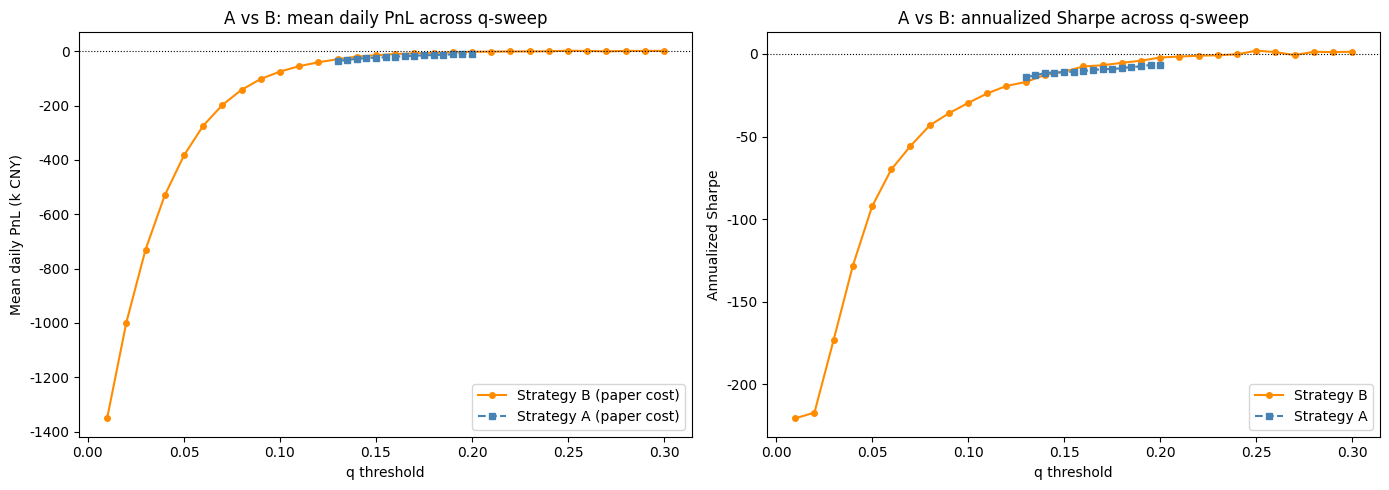

In [36]:
sweep_B_df = run_parameter_sweep(
    features_df=all_features_B,
    feature_cols=FEATURE_COLS_B,
    target_col=TARGET_COL,
    day_col=DAY_COL,
    session_col=SESSION_COL,
    bid_col=BID_COL,
    ask_col=ASK_COL,
    time_col=TIME_COL,
    q_values=[round(0.01 + i * 0.01, 2) for i in range(30)],  # 0.01 ~ 0.30
    tr_cost_open=TR_COST_PAPER, tr_cost_close=TR_COST_PAPER,
    contract_multiplier=CONTRACT_MULT,
    trading_hours=TRADING_HOURS,
    trading_days=ALL_DAYS,
)
display(sweep_B_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(sweep_B_df['q'], sweep_B_df['mean_daily_pnl'] / 1e3,
         'o-', color='darkorange', linewidth=1.5, markersize=4, label='Strategy B (paper cost)')
ax1.plot(sweep_df['q'], sweep_df['mean_daily_pnl'] / 1e3,
         's--', color='steelblue', linewidth=1.5, markersize=5, label='Strategy A (paper cost)')
ax1.axhline(0, color='black', linewidth=0.8, linestyle=':')
ax1.set_xlabel('q threshold')
ax1.set_ylabel('Mean daily PnL (k CNY)')
ax1.set_title('A vs B: mean daily PnL across q-sweep')
ax1.legend()

ax2 = axes[1]
ax2.plot(sweep_B_df['q'], sweep_B_df['annualized_sharpe'],
         'o-', color='darkorange', linewidth=1.5, markersize=4, label='Strategy B')
ax2.plot(sweep_df['q'], sweep_df['annualized_sharpe'],
         's--', color='steelblue', linewidth=1.5, markersize=5, label='Strategy A')
ax2.axhline(0, color='black', linewidth=0.8, linestyle=':')
ax2.set_xlabel('q threshold')
ax2.set_ylabel('Annualized Sharpe')
ax2.set_title('A vs B: annualized Sharpe across q-sweep')
ax2.legend()

plt.tight_layout()
plt.show()

### 8.3 Optimal Threshold Backtest *(In-Sample Ceiling)*

The threshold selected here maximises Sharpe ratio over the full dataset. This figure is **not** an out-of-sample estimate. See Sections 12–13 for the held-out and walk-forward equivalents.

In [37]:
best_q_A = float(sweep_df.loc[sweep_df['mean_daily_pnl'].idxmax(), 'q'])
best_q_B = float(sweep_B_df.loc[sweep_B_df['mean_daily_pnl'].idxmax(), 'q'])

print(f'Strategy A  best q (in-sample): {best_q_A:.3f}')
print(f'Strategy B  best q (in-sample): {best_q_B:.3f}')
print()

print('Strategy A sweep range:')
print(sweep_df[['q', 'mean_daily_pnl', 'annualized_sharpe', 'mean_daily_volume']]
      .to_string(index=False))
print()
print('Strategy B sweep range:')
print(sweep_B_df[['q', 'mean_daily_pnl', 'annualized_sharpe', 'mean_daily_volume']]
      .to_string(index=False))

Strategy A  best q (in-sample): 0.200
Strategy B  best q (in-sample): 0.250

Strategy A sweep range:
    q  mean_daily_pnl  annualized_sharpe  mean_daily_volume
0.130   -35867.898438         -14.067147         398.103448
0.135   -32251.021484         -13.014022         367.517241
0.140   -27853.523438         -11.516334         339.775862
0.145   -25609.238281         -11.236172         315.500000
0.150   -23692.574219         -11.013981         292.482759
0.155   -22041.966797         -10.812544         273.275862
0.160   -19880.107422         -10.279285         254.189655
0.165   -18458.382812          -9.801696         237.793103
0.170   -16450.693359          -9.126621         222.189655
0.175   -15315.579102          -9.173743         207.603448
0.180   -14175.486328          -8.613998         195.344828
0.185   -13012.437500          -7.920041         183.327586
0.190   -11731.009766          -7.512340         172.689655
0.195   -10405.497070          -6.598812         163.310345

In [38]:
results_A_best = run_backtest(
    features_df=features_full, feature_cols=FEATURE_COLS,
    target_col=TARGET_COL, day_col=DAY_COL, session_col=SESSION_COL,
    bid_col=BID_COL, ask_col=ASK_COL, time_col=TIME_COL,
    threshold=best_q_A, tr_cost_open=TR_COST_PAPER, tr_cost_close=TR_COST_PAPER,
    contract_multiplier=CONTRACT_MULT, trading_hours=TRADING_HOURS,
)
metrics_A_best = compute_performance_metrics(
    results_A_best, trading_days=ALL_DAYS, verbose=False,
)

results_B_best = run_backtest(
    features_df=all_features_B, feature_cols=FEATURE_COLS_B,
    target_col=TARGET_COL, day_col=DAY_COL, session_col=SESSION_COL,
    bid_col=BID_COL, ask_col=ASK_COL, time_col=TIME_COL,
    threshold=best_q_B, tr_cost_open=TR_COST_PAPER, tr_cost_close=TR_COST_PAPER,
    contract_multiplier=CONTRACT_MULT, trading_hours=TRADING_HOURS,
)
metrics_B_best = compute_performance_metrics(
    results_B_best, trading_days=ALL_DAYS, verbose=False,
)

KEY_METRICS_EXT = ['mean_daily_pnl', 'win_rate_per_trade',
                   'annualized_sharpe', 'n_trades', 'mean_daily_trade_volume']

summary = pd.DataFrame({
    'A  q=0.20   paper (2.5e-5)'   : {k: metrics_paper[k]     for k in KEY_METRICS_EXT},
    'A  q=0.20   current (open=2.3e-5, close=2.3e-4)' : {k: metrics_current[k]   for k in KEY_METRICS_EXT},
    f'A  q={best_q_A:.2f}  paper (best)'  : {k: metrics_A_best[k]  for k in KEY_METRICS_EXT},
    'B  q=0.20   paper (2.5e-5)'   : {k: metrics_B_paper[k]   for k in KEY_METRICS_EXT},
    'B  q=0.20   current (open=2.3e-5, close=2.3e-4)' : {k: metrics_B_current[k] for k in KEY_METRICS_EXT},
    f'B  q={best_q_B:.2f}  paper (best)'  : {k: metrics_B_best[k]  for k in KEY_METRICS_EXT},
}).T
summary.index.name = 'Scenario'
display(summary)

,mean_daily_pnl,win_rate_per_trade,annualized_sharpe,n_trades,mean_daily_trade_volume
Scenario,,,,,
A q=0.20 paper (2.5e-5),-10300.217773,0.347544,-6.905704,8937.0,154.086207
"A q=0.20 current (open=2.3e-5, close=2.3e-4)",-53121.101562,0.237328,-12.968255,8937.0,154.086207
A q=0.20 paper (best),-10300.217773,0.347544,-6.905704,8937.0,154.086207
B q=0.20 paper (2.5e-5),-2202.305908,0.408898,-2.154281,14116.0,243.379310
"B q=0.20 current (open=2.3e-5, close=2.3e-4)",-70170.046875,0.252054,-23.001835,14116.0,243.379310
B q=0.25 paper (best),1806.822144,0.425972,1.955575,6761.0,116.568966


## 9. Forecast Horizon Sweep — Strategy B, k = 5..120

Sweeping k in [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 105, 110, 115, 120]
threshold=best_q_B=0.250  tr_cost_open=TR_COST_PAPER, tr_cost_close=TR_COST_PAPER=2.5e-05

  k=  5  PnL=   1806.8  Sharpe= 1.956  vol=  117  R2=0.0483
  k= 10  PnL=   1107.2  Sharpe= 1.315  vol=  131  R2=0.0323
  k= 15  PnL=    270.4  Sharpe= 0.276  vol=  139  R2=0.0238
  k= 20  PnL=    361.3  Sharpe= 0.325  vol=  143  R2=0.0184
  k= 25  PnL=    195.3  Sharpe= 0.190  vol=  146  R2=0.0147
  k= 30  PnL=    -66.4  Sharpe=-0.064  vol=  148  R2=0.0120
  k= 35  PnL=     45.4  Sharpe= 0.041  vol=  149  R2=0.0098
  k= 40  PnL=   -228.2  Sharpe=-0.208  vol=  151  R2=0.0080
  k= 45  PnL=     91.8  Sharpe= 0.085  vol=  153  R2=0.0064
  k= 50  PnL=    -88.2  Sharpe=-0.086  vol=  154  R2=0.0051
  k= 55  PnL=    -97.8  Sharpe=-0.096  vol=  155  R2=0.0042
  k= 60  PnL=    437.5  Sharpe= 0.391  vol=  156  R2=0.0033
  k= 65  PnL=   -611.6  Sharpe=-0.582  vol=  158  R2=0.0025
  k= 70  PnL= 

,mean_daily_pnl,annualized_sharpe,mean_daily_trade_volume,r2_proxy
k,,,,
5,1806.822144,1.955575,116.568966,0.048294
10,1107.240967,1.314737,131.344828,0.032256
15,270.376190,0.275789,139.086207,0.023798
20,361.267609,0.325099,143.413793,0.018383
25,195.325302,0.189761,145.568966,0.014726
30,-66.431404,-0.063646,147.913793,0.011983
35,45.381905,0.041426,149.344828,0.009806
40,-228.228653,-0.208289,151.293103,0.008002
45,91.819641,0.085332,152.793103,0.006437


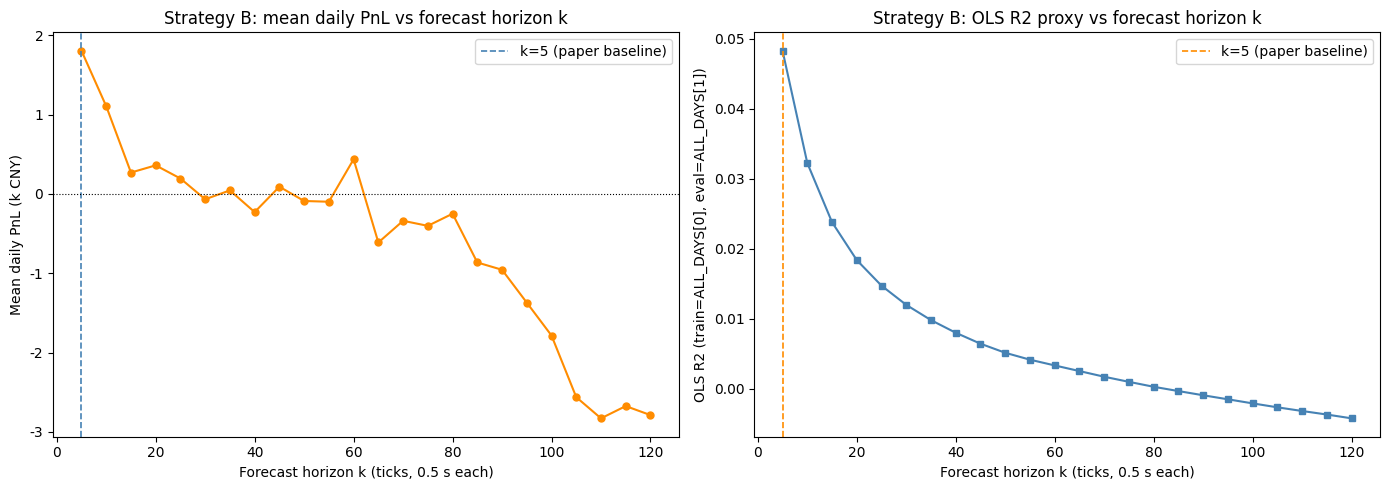

Best forecast horizon by Sharpe: k=5  (annualized Sharpe=1.956)


In [39]:
K_SWEEP = list(range(5, 125, 5))  # [5, 10, 15, ..., 120]

print(f'Sweeping k in {K_SWEEP}')
print(f'threshold=best_q_B={best_q_B:.3f}  tr_cost_open=TR_COST_PAPER, tr_cost_close=TR_COST_PAPER={TR_COST_PAPER}')
print()

k_records = []

for k_val in K_SWEEP:
    # Rebuild dMid_response for this k
    df_main['dMid_response'] = (
        df_main.groupby([DAY_COL, SESSION_COL], group_keys=False)
        .apply(lambda g: compute_response(g, k=k_val))
    )

    # Rebuild Strategy B feature matrix (tail trim = k_val; head trim = L_B+1 = 6 unchanged)
    feats_k = (
        df_main.groupby([DAY_COL, SESSION_COL], group_keys=False)
        .apply(lambda g: build_feature_matrix_B(g, L=L_B, k=k_val))
        .join(df_main[[DAY_COL, SESSION_COL, BID_COL, ASK_COL, 'MidPrice', TIME_COL]])
        .reset_index(drop=True)
    )

    # Run backtest with paper cost and best_q_B threshold
    results_k = run_backtest(
        features_df=feats_k,
        feature_cols=FEATURE_COLS_B,
        target_col=TARGET_COL,
        day_col=DAY_COL,
        session_col=SESSION_COL,
        bid_col=BID_COL,
        ask_col=ASK_COL,
        time_col=TIME_COL,
        threshold=best_q_B,
        tr_cost_open=TR_COST_PAPER, tr_cost_close=TR_COST_PAPER,
        contract_multiplier=CONTRACT_MULT,
        trading_hours=TRADING_HOURS,
    )
    m = compute_performance_metrics(results_k, trading_days=ALL_DAYS, verbose=False)

    # OLS R² proxy: fit on ALL_DAYS[0], evaluate on ALL_DAYS[1]
    train_df = feats_k[feats_k[DAY_COL] == ALL_DAYS[0]]
    test_df  = feats_k[feats_k[DAY_COL] == ALL_DAYS[1]]
    coefs_k  = fit_ols_model(train_df[FEATURE_COLS_B].values, train_df[TARGET_COL].values)
    if coefs_k is not None and len(test_df) > 0:
        X_aug  = np.column_stack([np.ones(len(test_df)), test_df[FEATURE_COLS_B].values])
        y_pred = X_aug @ coefs_k
        y_true = test_df[TARGET_COL].values
        ss_res = np.sum((y_true - y_pred) ** 2)
        ss_tot = np.sum((y_true - y_true.mean()) ** 2)
        r2_k   = float(1 - ss_res / ss_tot) if ss_tot > 0 else 0.0
    else:
        r2_k = np.nan

    k_records.append({
        'k':                       k_val,
        'mean_daily_pnl':          m['mean_daily_pnl'],
        'annualized_sharpe':       m['annualized_sharpe'],
        'mean_daily_trade_volume': m['mean_daily_trade_volume'],
        'r2_proxy':                r2_k,
    })
    pnl, sharpe, vol = m['mean_daily_pnl'], m['annualized_sharpe'], m['mean_daily_trade_volume']
    print(f'  k={k_val:3d}  PnL={pnl:9.1f}  Sharpe={sharpe:6.3f}  vol={vol:5.0f}  R2={r2_k:.4f}')

# Restore dMid_response to paper baseline (k=k_B=5)
df_main['dMid_response'] = (
    df_main.groupby([DAY_COL, SESSION_COL], group_keys=False)
    .apply(lambda g: compute_response(g, k=k_B))
)

k_sweep_df = pd.DataFrame(k_records)

display(k_sweep_df.set_index('k'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(k_sweep_df['k'], k_sweep_df['mean_daily_pnl'] / 1e3,
         'o-', color='darkorange', linewidth=1.5, markersize=5)
ax1.axvline(5, color='steelblue', linewidth=1.2, linestyle='--', label='k=5 (paper baseline)')
ax1.axhline(0, color='black', linewidth=0.8, linestyle=':')
ax1.set_xlabel('Forecast horizon k (ticks, 0.5 s each)')
ax1.set_ylabel('Mean daily PnL (k CNY)')
ax1.set_title('Strategy B: mean daily PnL vs forecast horizon k')
ax1.legend()

ax2 = axes[1]
ax2.plot(k_sweep_df['k'], k_sweep_df['r2_proxy'],
         's-', color='steelblue', linewidth=1.5, markersize=5)
ax2.axvline(5, color='darkorange', linewidth=1.2, linestyle='--', label='k=5 (paper baseline)')
ax2.set_xlabel('Forecast horizon k (ticks, 0.5 s each)')
ax2.set_ylabel('OLS R2 (train=ALL_DAYS[0], eval=ALL_DAYS[1])')
ax2.set_title('Strategy B: OLS R2 proxy vs forecast horizon k')
ax2.legend()

plt.tight_layout()
plt.show()

best_k      = int(k_sweep_df.loc[k_sweep_df['annualized_sharpe'].idxmax(), 'k'])
best_sharpe = float(k_sweep_df['annualized_sharpe'].max())
print(f'Best forecast horizon by Sharpe: k={best_k}  (annualized Sharpe={best_sharpe:.3f})')

## 10. k=10 Validation & Strategy B Threshold Optimisation *(In-Sample)*

> **In-sample caveat**: parameter optimisation here is performed over all 2026 trading days. Results should be interpreted as sensitivity analysis rather than performance forecasts. Walk-forward out-of-sample results are in Section 13.

Precomputing signals for parameter sweep...
Signals cached for 116 (day, session) pairs.
  q=0.050  mean_daily_pnl=  -371,328  t=-43.612  sharpe=-90.906
  q=0.060  mean_daily_pnl=  -268,218  t=-32.479  sharpe=-67.699
  q=0.070  mean_daily_pnl=  -193,516  t=-25.914  sharpe=-54.015
  q=0.080  mean_daily_pnl=  -138,570  t=-20.123  sharpe=-41.946
  q=0.090  mean_daily_pnl=  -100,849  t=-16.306  sharpe=-33.988
  q=0.100  mean_daily_pnl=   -73,680  t=-13.549  sharpe=-28.242
  q=0.110  mean_daily_pnl=   -54,938  t=-10.945  sharpe=-22.813
  q=0.120  mean_daily_pnl=   -40,661  t=-8.991  sharpe=-18.740
  q=0.130  mean_daily_pnl=   -29,459  t=-7.344  sharpe=-15.309
  q=0.140  mean_daily_pnl=   -22,182  t=-6.296  sharpe=-13.124
  q=0.150  mean_daily_pnl=   -15,030  t=-4.675  sharpe=-9.745
  q=0.160  mean_daily_pnl=   -11,642  t=-3.884  sharpe=-8.095
  q=0.170  mean_daily_pnl=    -7,941  t=-2.898  sharpe=-6.040
  q=0.180  mean_daily_pnl=    -6,032  t=-2.336  sharpe=-4.870
  q=0.190  mean_daily_pnl=

,q,mean_daily_pnl,stderr,t_stat,p_value,annualized_sharpe,avg_daily_sharpe,win_rate_per_trade,mean_daily_volume,days_with_profit,days_with_loss
0,0.05,-371327.968750,8514.319439,-43.612175,1.000000,-90.906303,-0.582311,0.168723,3632.155172,0,58
1,0.06,-268217.812500,8258.307286,-32.478546,1.000000,-67.699093,-0.469770,0.197213,2951.293103,0,58
2,0.07,-193515.968750,7467.710741,-25.913694,1.000000,-54.015151,-0.378909,0.225386,2400.862069,0,58
3,0.08,-138570.375000,6886.002214,-20.123486,1.000000,-41.945899,-0.303800,0.251917,1958.431034,0,58
4,0.09,-100849.312500,6184.842276,-16.305883,1.000000,-33.988390,-0.246928,0.275076,1615.293103,1,57
5,0.10,-73679.757812,5437.925636,-13.549239,1.000000,-28.242374,-0.201833,0.295938,1339.982759,2,56
6,0.11,-54938.468750,5019.622836,-10.944741,1.000000,-22.813490,-0.166390,0.313380,1119.000000,2,56
7,0.12,-40660.707031,4522.593622,-8.990573,1.000000,-18.740175,-0.138245,0.328366,935.931034,3,55
8,0.13,-29458.851562,4011.125060,-7.344286,1.000000,-15.308614,-0.110771,0.343461,784.810345,3,55
9,0.14,-22181.578125,3523.040585,-6.296146,1.000000,-13.123844,-0.091646,0.356734,662.620690,5,53


Current cost sweep (TR_COST_CLOSE):


,q,mean_daily_pnl,stderr,t_stat,p_value,annualized_sharpe,avg_daily_sharpe,win_rate_per_trade,mean_daily_volume,days_with_profit,days_with_loss
0,0.05,-1.392986e+06,23153.218170,-60.163807,1.000000,-125.406944,-2.177645,0.036385,3632.155172,0,58
1,0.06,-1.098037e+06,22828.585583,-48.099201,1.000000,-100.259179,-1.912930,0.047857,2951.293103,0,58
2,0.07,-8.682916e+05,21576.426922,-40.242603,1.000000,-83.882686,-1.684581,0.060747,2400.862069,0,58
3,0.08,-6.887608e+05,20401.029182,-33.761082,1.000000,-70.372443,-1.484704,0.075756,1958.431034,0,58
4,0.09,-5.544504e+05,18754.216728,-29.564037,1.000000,-61.624020,-1.319332,0.090034,1615.293103,0,58
5,0.10,-4.498314e+05,16914.553079,-26.594345,1.000000,-55.433915,-1.177795,0.105508,1339.982759,0,58
6,0.11,-3.689186e+05,15668.306286,-23.545528,1.000000,-49.078890,-1.055280,0.121291,1119.000000,0,58
7,0.12,-3.031242e+05,14092.434183,-21.509714,1.000000,-44.835389,-0.947245,0.136965,935.931034,0,58
8,0.13,-2.494163e+05,13118.692349,-19.012285,1.000000,-39.629684,-0.848065,0.153606,784.810345,0,58
9,0.14,-2.077882e+05,12007.452163,-17.304939,1.000000,-36.070849,-0.770495,0.168375,662.620690,0,58


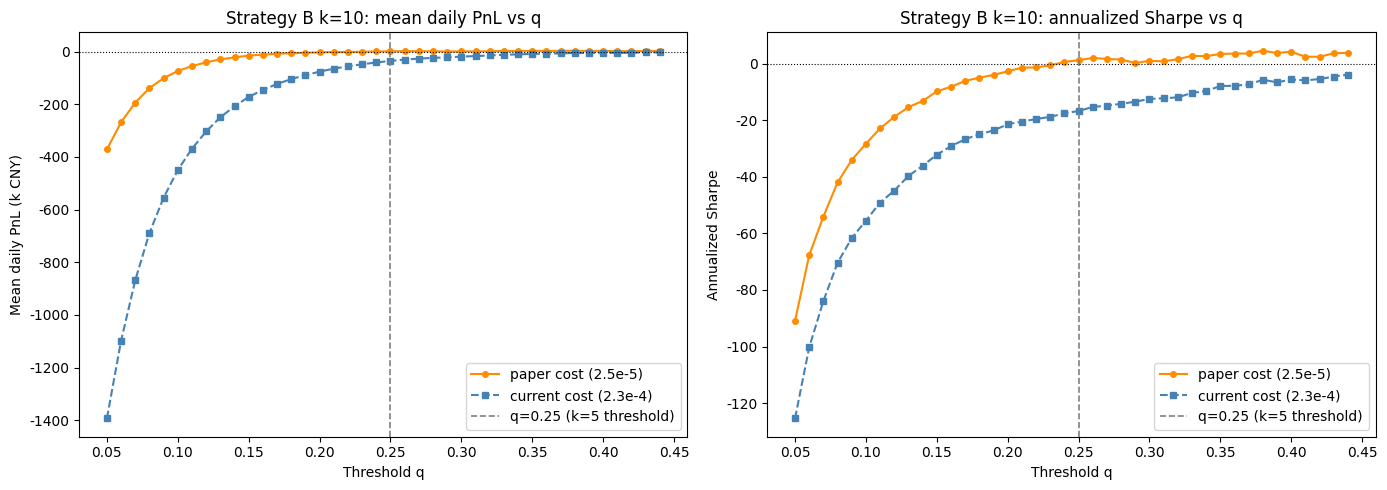

k=10  paper cost:   best q=0.38  PnL=3395.5  Sharpe=4.657  vol=31
k=10  current cost: best q=0.44  PnL=-2887.4  Sharpe=-3.799  vol=19


In [40]:
# Rebuild dMid_response and Strategy B feature matrix for k=10
k_val10 = 10

df_main['dMid_response'] = (
    df_main.groupby([DAY_COL, SESSION_COL], group_keys=False)
    .apply(lambda g: compute_response(g, k=k_val10))
)

all_features_B10 = (
    df_main.groupby([DAY_COL, SESSION_COL], group_keys=False)
    .apply(lambda g: build_feature_matrix_B(g, L=L_B, k=k_val10))
    .join(df_main[[DAY_COL, SESSION_COL, BID_COL, ASK_COL, 'MidPrice', TIME_COL]])
    .reset_index(drop=True)
)

q_values_10 = [round(0.05 + i * 0.01, 2) for i in range(40)]  # 0.05..0.44

# Sweep paper cost
sweep_10_paper = run_parameter_sweep(
    features_df=all_features_B10,
    feature_cols=FEATURE_COLS_B,
    target_col=TARGET_COL,
    day_col=DAY_COL,
    session_col=SESSION_COL,
    bid_col=BID_COL,
    ask_col=ASK_COL,
    time_col=TIME_COL,
    q_values=q_values_10,
    tr_cost_open=TR_COST_PAPER, tr_cost_close=TR_COST_PAPER,
    contract_multiplier=CONTRACT_MULT,
    trading_hours=TRADING_HOURS,
    trading_days=ALL_DAYS,
)

# Sweep current cost
sweep_10_current = run_parameter_sweep(
    features_df=all_features_B10,
    feature_cols=FEATURE_COLS_B,
    target_col=TARGET_COL,
    day_col=DAY_COL,
    session_col=SESSION_COL,
    bid_col=BID_COL,
    ask_col=ASK_COL,
    time_col=TIME_COL,
    q_values=q_values_10,
    tr_cost_open=TR_COST_OPEN, tr_cost_close=TR_COST_CLOSE,
    contract_multiplier=CONTRACT_MULT,
    trading_hours=TRADING_HOURS,
    trading_days=ALL_DAYS,
)

print('Paper cost sweep (TR_COST_PAPER):')
display(sweep_10_paper)
print('Current cost sweep (TR_COST_CLOSE):')
display(sweep_10_current)

# Two-panel plot: PnL vs q (left) and Sharpe vs q (right)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(sweep_10_paper['q'], sweep_10_paper['mean_daily_pnl'] / 1e3,
         'o-', color='darkorange', linewidth=1.5, markersize=4, label='paper cost (2.5e-5)')
ax1.plot(sweep_10_current['q'], sweep_10_current['mean_daily_pnl'] / 1e3,
         's--', color='steelblue', linewidth=1.5, markersize=4, label='current cost (2.3e-4)')
ax1.axvline(0.25, color='gray', linewidth=1.2, linestyle='--', label='q=0.25 (k=5 threshold)')
ax1.axhline(0, color='black', linewidth=0.8, linestyle=':')
ax1.set_xlabel('Threshold q')
ax1.set_ylabel('Mean daily PnL (k CNY)')
ax1.set_title('Strategy B k=10: mean daily PnL vs q')
ax1.legend()

ax2 = axes[1]
ax2.plot(sweep_10_paper['q'], sweep_10_paper['annualized_sharpe'],
         'o-', color='darkorange', linewidth=1.5, markersize=4, label='paper cost (2.5e-5)')
ax2.plot(sweep_10_current['q'], sweep_10_current['annualized_sharpe'],
         's--', color='steelblue', linewidth=1.5, markersize=4, label='current cost (2.3e-4)')
ax2.axvline(0.25, color='gray', linewidth=1.2, linestyle='--', label='q=0.25 (k=5 threshold)')
ax2.axhline(0, color='black', linewidth=0.8, linestyle=':')
ax2.set_xlabel('Threshold q')
ax2.set_ylabel('Annualized Sharpe')
ax2.set_title('Strategy B k=10: annualized Sharpe vs q')
ax2.legend()

plt.tight_layout()
plt.show()

# Best q by Sharpe for each cost scenario
best_q10_paper   = float(sweep_10_paper.loc[sweep_10_paper['annualized_sharpe'].idxmax(), 'q'])
best_q10_current = float(sweep_10_current.loc[sweep_10_current['annualized_sharpe'].idxmax(), 'q'])

row_paper   = sweep_10_paper.loc[sweep_10_paper['annualized_sharpe'].idxmax()]
row_current = sweep_10_current.loc[sweep_10_current['annualized_sharpe'].idxmax()]

pnl_p, sh_p, vol_p     = row_paper['mean_daily_pnl'], row_paper['annualized_sharpe'], row_paper['mean_daily_volume']
pnl_c, sh_c, vol_c     = row_current['mean_daily_pnl'], row_current['annualized_sharpe'], row_current['mean_daily_volume']

print(f'k=10  paper cost:   best q={best_q10_paper:.2f}  PnL={pnl_p:.1f}  Sharpe={sh_p:.3f}  vol={vol_p:.0f}')
print(f'k=10  current cost: best q={best_q10_current:.2f}  PnL={pnl_c:.1f}  Sharpe={sh_c:.3f}  vol={vol_c:.0f}')

# Restore dMid_response to paper baseline (k=k_B=5)
df_main['dMid_response'] = (
    df_main.groupby([DAY_COL, SESSION_COL], group_keys=False)
    .apply(lambda g: compute_response(g, k=k_B))
)


## 11. Strategy B+LD vs Strategy B -- Three Cost Scenarios

Add `LDistance_diff` (volume-weighted mean depth distance: ask depth centre - bid depth centre)
as the 14th OLS feature (raw, no spread normalisation; method from `06_lob_signals_validation`
and `07_strategy_enhanced`).  Run B and B+LD under all three cost regimes at **q=0.20, k=5**
(same fixed parameters as Section 6 -- not the sweep optimum).

In [41]:
# 11.1 -- Load 5-level LOB for the same date range; compute and merge LDistance_diff into df_main
_5lob_cols = [
    'InstruID', 'TradDay', 'ActionDateTime',
    'BidPrice1', 'BidVolume1', 'BidPrice2', 'BidVolume2',
    'BidPrice3', 'BidVolume3', 'BidPrice4', 'BidVolume4',
    'BidPrice5', 'BidVolume5',
    'AskPrice1', 'AskVolume1', 'AskPrice2', 'AskVolume2',
    'AskPrice3', 'AskVolume3', 'AskPrice4', 'AskVolume4',
    'AskPrice5', 'AskVolume5',
]
df_lob5 = load_date_range(20260202, 20260508, columns=_5lob_cols)
df_lob5['ActionDateTime'] = pd.to_datetime(df_lob5['ActionDateTime'], format='%Y%m%d %H:%M:%S.%f')
df_lob5['time_seconds'] = (
    df_lob5['ActionDateTime'].dt.hour * 3600
    + df_lob5['ActionDateTime'].dt.minute * 60
    + df_lob5['ActionDateTime'].dt.second
    + df_lob5['ActionDateTime'].dt.microsecond / 1_000_000
)

# Volume-weighted depth distance (same formula as 06/07)
_mid_col = ((df_lob5['BidPrice1'] + df_lob5['AskPrice1']) / 2).values.reshape(-1, 1)
bid_p5 = df_lob5[['BidPrice1','BidPrice2','BidPrice3','BidPrice4','BidPrice5']].values
bid_v5 = df_lob5[['BidVolume1','BidVolume2','BidVolume3','BidVolume4','BidVolume5']].values
ask_p5 = df_lob5[['AskPrice1','AskPrice2','AskPrice3','AskPrice4','AskPrice5']].values
ask_v5 = df_lob5[['AskVolume1','AskVolume2','AskVolume3','AskVolume4','AskVolume5']].values
bid_dist = _mid_col - bid_p5
ask_dist = ask_p5 - _mid_col
_bvs = bid_v5.sum(axis=1).clip(1e-9)
_avs = ask_v5.sum(axis=1).clip(1e-9)
df_lob5['LDistance_diff'] = (
    (ask_dist * ask_v5).sum(axis=1) / _avs
    - (bid_dist * bid_v5).sum(axis=1) / _bvs
)

# Merge into df_main on (InstruID, TradDay, time_seconds) -- exact float match from same DB + same parser
_merge_key = ['InstruID', 'TradDay', 'time_seconds']
_n_before = len(df_main)
df_main = df_main.merge(
    df_lob5[_merge_key + ['LDistance_diff']],
    on=_merge_key,
    how='left',
)
assert len(df_main) == _n_before, 'merge changed row count'

_nan_n = df_main['LDistance_diff'].isna().sum()
if _nan_n > 0:
    print(f'NOTE: {_nan_n} NaN in LDistance_diff ({_nan_n/len(df_main):.4%}) -- forward-filling within sessions')
    df_main['LDistance_diff'] = (
        df_main.groupby([DAY_COL, SESSION_COL])['LDistance_diff']
        .transform(lambda s: s.ffill().bfill())
    )

print(f'LDistance_diff added: {df_main["LDistance_diff"].notna().sum():,} valid rows')
print(f'  mean={df_main["LDistance_diff"].mean():.4f}  std={df_main["LDistance_diff"].std():.4f}')


LDistance_diff added: 1,559,260 valid rows
  mean=-0.0006  std=0.2945


### 11.1b  LDistance_diff Autocorrelation (ACF) -- 2026 Data

Compute ACF at lags 1-10 (FFT-accelerated, same as `06_lob_signals_validation` Section 2.5).
Note: the series spans session boundaries; lag-1 between the last tick of one session
and the first tick of the next is physically ~90 min, not ~0.5 s. Results are reported both pooled and split by session for comparison.

Method                   Lag1   Lag2   Lag3   Lag4   Lag5   Lag6   Lag7   Lag8   Lag9  Lag10
--------------------------------------------------------------------------------------------
Pooled (full series)    0.620  0.459  0.362  0.302  0.261  0.228  0.203  0.180  0.161  0.149
Per-session avg         0.628  0.469  0.373  0.314  0.272  0.239  0.212  0.188  0.170  0.156


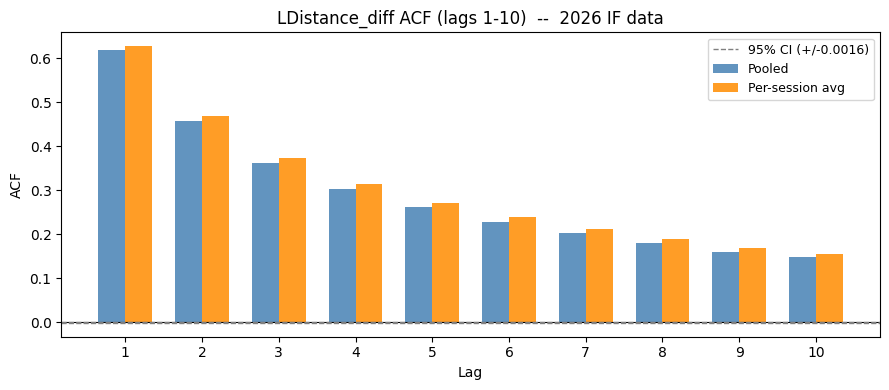

In [42]:
# 11.1b -- ACF of LDistance_diff (lags 1-10, FFT, replicating 06 Section 2.5)
from statsmodels.tsa.stattools import acf as _acf

NLAGS = 10

# --- Pooled ACF (same as 06: drop NaN, treat full series as one vector) ---
_ld_series = df_main['LDistance_diff'].dropna()
_acf_pooled = _acf(_ld_series, nlags=NLAGS, fft=True)

# --- Per-session ACF: average ACF across all (TradDay, session) groups ---
def _session_acf(grp):
    s = grp['LDistance_diff'].dropna()
    if len(s) <= NLAGS:
        return None
    return _acf(s, nlags=NLAGS, fft=True)[1:]  # drop lag-0

_session_acfs = (
    df_main.groupby([DAY_COL, SESSION_COL])
    .apply(_session_acf)
    .dropna()
)
_acf_per_session = np.vstack(_session_acfs.values).mean(axis=0)

# --- Print table ---
_header = f"{'Method':<22}" + "".join(f"{'Lag'+str(i):>7}" for i in range(1, NLAGS + 1))
print(_header)
print('-' * len(_header))
_row_pooled  = f"{'Pooled (full series)':<22}" + "".join(f"{v:7.3f}" for v in _acf_pooled[1:])
_row_session = f"{'Per-session avg':<22}" + "".join(f"{v:7.3f}" for v in _acf_per_session)
print(_row_pooled)
print(_row_session)

# --- Bar plot ---
lags = np.arange(1, NLAGS + 1)
fig, ax = plt.subplots(figsize=(9, 4))
w = 0.35
ax.bar(lags - w/2, _acf_pooled[1:],    width=w, label='Pooled',           color='steelblue',  alpha=0.85)
ax.bar(lags + w/2, _acf_per_session,   width=w, label='Per-session avg',  color='darkorange', alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)
_ci = 1.96 / np.sqrt(len(_ld_series))
ax.axhline( _ci, color='gray', linewidth=1, linestyle='--', label=f'95% CI (+/-{_ci:.4f})')
ax.axhline(-_ci, color='gray', linewidth=1, linestyle='--')
ax.set_xlabel('Lag')
ax.set_ylabel('ACF')
ax.set_title('LDistance_diff ACF (lags 1-10)  --  2026 IF data')
ax.set_xticks(lags)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


In [43]:
# 11.2 -- Build Strategy B+LD feature matrix (13 B features + LDistance_diff_raw)
def build_features_B_enhanced(df, L=L_B, k=k_B):
    n      = len(df)
    spread = df['Spread']
    X_voi  = pd.DataFrame(
        {f'VOI_t{j}': df['VOI'].shift(j) / spread for j in range(L + 1)},
        index=df.index,
    )
    X_oir  = pd.DataFrame(
        {f'OIR_t{j}': df['OIR'].shift(j) / spread for j in range(L + 1)},
        index=df.index,
    )
    X_mpb  = (df['MPB'] / spread).rename('MPB_norm')
    X_ld   = df['LDistance_diff'].rename('LDistance_diff_raw')
    y      = compute_response(df, k=k).rename('y')
    out    = pd.concat([X_voi, X_oir, X_mpb, X_ld, y], axis=1).iloc[L + 1 : n - k]
    assert out.isna().sum().sum() == 0, (
        f'NaN in B+LD features: {out.isna().sum()[out.isna().sum() > 0]}'
    )
    return out.copy()

FEATURE_COLS_B_ENH = FEATURE_COLS_B + ['LDistance_diff_raw']

_join_cols = [DAY_COL, SESSION_COL, BID_COL, ASK_COL, 'MidPrice', TIME_COL]
all_features_B_enhanced = (
    df_main.groupby([DAY_COL, SESSION_COL], group_keys=False)
    .apply(build_features_B_enhanced)
    .join(df_main[_join_cols])
    .reset_index(drop=True)
)
assert all_features_B_enhanced[FEATURE_COLS_B_ENH + ['y']].isna().sum().sum() == 0

print(f'all_features_B_enhanced: {all_features_B_enhanced.shape}')
print(f'Features ({len(FEATURE_COLS_B_ENH)}): {FEATURE_COLS_B_ENH}')


all_features_B_enhanced: (1557962, 21)
Features (14): ['VOI_t0', 'VOI_t1', 'VOI_t2', 'VOI_t3', 'VOI_t4', 'VOI_t5', 'OIR_t0', 'OIR_t1', 'OIR_t2', 'OIR_t3', 'OIR_t4', 'OIR_t5', 'MPB_norm', 'LDistance_diff_raw']


In [44]:
# 11.3 -- Backtest B+LD under paper / current / zero cost  (q=0.20, k=5 -- same as B baseline)
_bt_BLD = dict(
    features_df=all_features_B_enhanced,
    feature_cols=FEATURE_COLS_B_ENH,
    target_col=TARGET_COL,
    day_col=DAY_COL,
    session_col=SESSION_COL,
    bid_col=BID_COL,
    ask_col=ASK_COL,
    time_col=TIME_COL,
    threshold=0.2,
    contract_multiplier=CONTRACT_MULT,
    trading_hours=TRADING_HOURS,
)

print('Running B+LD (paper cost) ...')
results_BLD_paper   = run_backtest(**_bt_BLD, tr_cost_open=TR_COST_PAPER, tr_cost_close=TR_COST_PAPER)
print('Running B+LD (current cost) ...')
results_BLD_current = run_backtest(**_bt_BLD, tr_cost_open=TR_COST_OPEN,  tr_cost_close=TR_COST_CLOSE)
print('Running B+LD (zero cost) ...')
results_BLD_zero    = run_backtest(**_bt_BLD, tr_cost_open=TR_COST_ZERO,  tr_cost_close=TR_COST_ZERO)

metrics_BLD_paper   = compute_performance_metrics(results_BLD_paper,   trading_days=ALL_DAYS, output_dir=None, verbose=False)
metrics_BLD_current = compute_performance_metrics(results_BLD_current, trading_days=ALL_DAYS, output_dir=None, verbose=False)
metrics_BLD_zero    = compute_performance_metrics(results_BLD_zero,    trading_days=ALL_DAYS, output_dir=None, verbose=False)
print('All B+LD backtests done.')


Running B+LD (paper cost) ...
Running B+LD (current cost) ...
Running B+LD (zero cost) ...
All B+LD backtests done.


In [45]:
# 11.4 -- Side-by-side comparison: Strategy B vs B+LD, three cost scenarios

def _win_rate_days(res):
    pnls = [res[d]['daily_pnl'] for d in sorted(res)]
    return 100.0 * sum(p > 0 for p in pnls) / len(pnls) if pnls else float('nan')

def _summary_row(m, res):
    return {
        'Annualised Sharpe':     round(m['annualized_sharpe'], 3),
        'Mean daily PnL (CNY)':  round(m['mean_daily_pnl'],    1),
        'Std daily PnL (CNY)':   round(m['std_daily_pnl'],     1),
        'Win rate (% days>0)':   round(_win_rate_days(res),    1),
        'Total trades':          int(m['n_trades']),
    }

comparison_BLD = pd.DataFrame({
    'B   Paper (2.5e-5)':               _summary_row(metrics_B_paper,    results_B_paper),
    'B   Current (2.3e-5 / 2.3e-4)':   _summary_row(metrics_B_current,  results_B_current),
    'B   Zero cost':                    _summary_row(metrics_B_zero,     results_B_zero),
    'B+LD  Paper (2.5e-5)':             _summary_row(metrics_BLD_paper,   results_BLD_paper),
    'B+LD  Current (2.3e-5 / 2.3e-4)': _summary_row(metrics_BLD_current, results_BLD_current),
    'B+LD  Zero cost':                  _summary_row(metrics_BLD_zero,    results_BLD_zero),
}).T

comparison_BLD.index.name = 'Scenario'
display(comparison_BLD)


,Annualised Sharpe,Mean daily PnL (CNY),Std daily PnL (CNY),Win rate (% days>0),Total trades
Scenario,,,,,
B Paper (2.5e-5),-2.154,-2202.3,16228.4,46.6,14116.0
B Current (2.3e-5 / 2.3e-4),-23.002,-70170.0,48427.2,0.0,14116.0
B Zero cost,12.116,14538.5,19048.1,75.9,14116.0
B+LD Paper (2.5e-5),2.793,3031.9,17235.4,62.1,19709.0
B+LD Current (2.3e-5 / 2.3e-4),-23.194,-91758.1,62801.6,0.0,19709.0
B+LD Zero cost,16.925,26379.2,24742.3,94.8,19709.0


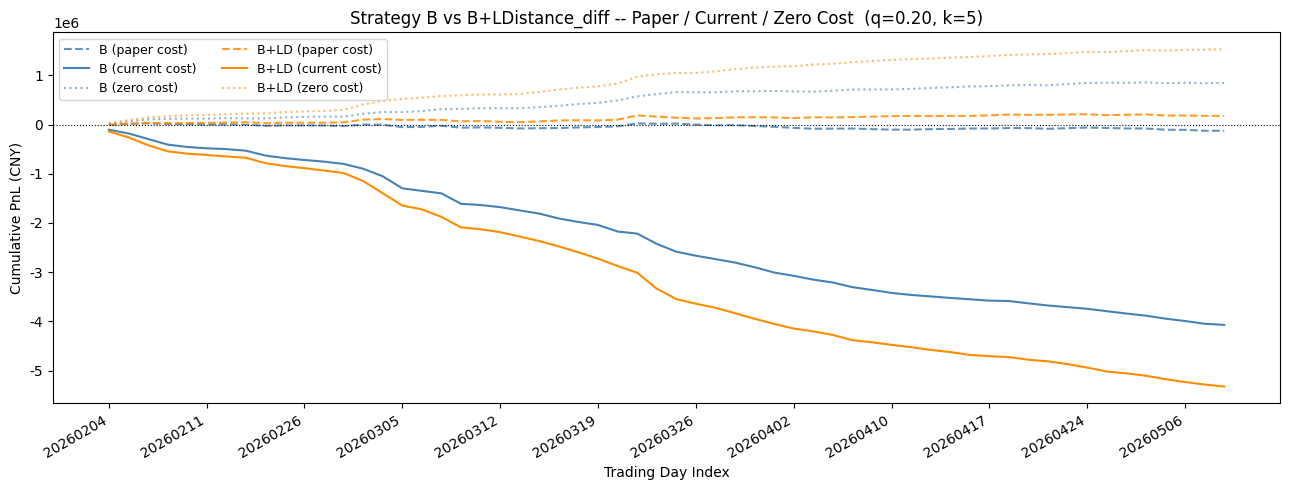

In [46]:
# 11.5 -- Cumulative PnL: B vs B+LD, paper / current / zero cost
_palette = {'B': 'steelblue', 'B+LD': 'darkorange'}
_styles  = {'paper': '--', 'current': '-', 'zero': ':'}
_alphas  = {'paper': 0.85, 'current': 1.0, 'zero': 0.6}

_scenarios_11 = [
    ('B',    'paper',   results_B_paper),
    ('B',    'current', results_B_current),
    ('B',    'zero',    results_B_zero),
    ('B+LD', 'paper',   results_BLD_paper),
    ('B+LD', 'current', results_BLD_current),
    ('B+LD', 'zero',    results_BLD_zero),
]

fig, ax = plt.subplots(figsize=(13, 5))
for strat, cost, res in _scenarios_11:
    days = sorted(res.keys())
    pnl  = np.array([res[d]['daily_pnl'] for d in days])
    ax.plot(range(len(days)), np.cumsum(pnl),
            color=_palette[strat], linestyle=_styles[cost],
            linewidth=1.5, alpha=_alphas[cost],
            label=f'{strat} ({cost} cost)')

ax.axhline(0, color='black', linewidth=0.8, linestyle=':')
ax.set_xlabel('Trading Day Index')
ax.set_ylabel('Cumulative PnL (CNY)')
ax.set_title('Strategy B vs B+LDistance_diff -- Paper / Current / Zero Cost  (q=0.20, k=5)')
ax.legend(ncol=2, fontsize=9)

_ref_days11 = sorted(results_BLD_paper.keys())
_step11 = max(1, len(_ref_days11) // 10)
ax.set_xticks(range(0, len(_ref_days11), _step11))
ax.set_xticklabels(
    [str(_ref_days11[j]) for j in range(0, len(_ref_days11), _step11)],
    rotation=30, ha='right'
)
plt.tight_layout()
plt.show()


## 12. Parameter Selection Bias: Train/Test Split Validation

Sections 8 and 10 optimised q and k in-sample. This section tests whether those parameters generalise by performing a **strict chronological split** — parameters are found on the training set only, then evaluated blind on held-out test data.

The Section 11 backtest fixed q=0.20, k=5 (same as Strategy B baseline).
Here we sweep q and k to find the optimum for B+LD — but to avoid in-sample bias
the sweep is done on a **train set only**, then the found parameters are evaluated
blind on a **held-out test set**.

- **Train set**: first 2/3 of trading days (chronological)
- **Test set**: remaining 1/3 — never touched during parameter search
- Sweep covers both paper (2.5e-5) and current (2.3e-5 / 2.3e-4) cost regimes
- OLS coefficients remain walk-forward within each set


In [47]:
# 12.1 -- chronological train/test split
_all_days_12 = sorted(df_main[DAY_COL].unique())
_n_train_12  = int(len(_all_days_12) * 2 / 3)

TRAIN_DAYS_12 = _all_days_12[:_n_train_12]
TEST_DAYS_12  = _all_days_12[_n_train_12:]

print(f"Total days : {len(_all_days_12)}")
print(f"Train days : {len(TRAIN_DAYS_12)}  ({TRAIN_DAYS_12[0]} -- {TRAIN_DAYS_12[-1]})")
print(f"Test  days : {len(TEST_DAYS_12)}   ({TEST_DAYS_12[0]} -- {TEST_DAYS_12[-1]})")

_feats_train_12 = all_features_B_enhanced[
    all_features_B_enhanced[DAY_COL].isin(TRAIN_DAYS_12)
].reset_index(drop=True)

print(f"\nTrain feature rows: {len(_feats_train_12):,}")


Total days : 59
Train days : 39  (20260203 -- 20260407)
Test  days : 20   (20260408 -- 20260508)

Train feature rows: 1,036,143


=== q sweep on TRAIN (current cost) ===
Precomputing signals for parameter sweep...
Signals cached for 76 (day, session) pairs.
  q=0.050  mean_daily_pnl=-1,618,810  t=-63.566  sharpe=-163.694
  q=0.100  mean_daily_pnl=  -630,216  t=-24.258  sharpe=-62.469
  q=0.150  mean_daily_pnl=  -258,110  t=-14.327  sharpe=-36.895
  q=0.200  mean_daily_pnl=  -112,507  t=-10.227  sharpe=-26.337
  q=0.250  mean_daily_pnl=   -52,478  t=-7.450  sharpe=-19.184
  q=0.300  mean_daily_pnl=   -26,389  t=-5.649  sharpe=-14.547
  q=0.350  mean_daily_pnl=    -8,819  t=-3.252  sharpe=-8.374
  q=0.400  mean_daily_pnl=    -5,104  t=-2.140  sharpe=-5.512
  q=0.450  mean_daily_pnl=    -3,418  t=-1.593  sharpe=-4.102
  q=0.500  mean_daily_pnl=    -4,328  t=-1.871  sharpe=-4.818
  q=0.550  mean_daily_pnl=    -4,622  t=-2.289  sharpe=-5.894
  q=0.600  mean_daily_pnl=    -3,836  t=-2.178  sharpe=-5.608
  q=0.650  mean_daily_pnl=    -2,239  t=-1.303  sharpe=-3.356
  q=0.700  mean_daily_pnl=       -12  t=-0.009  sharpe=

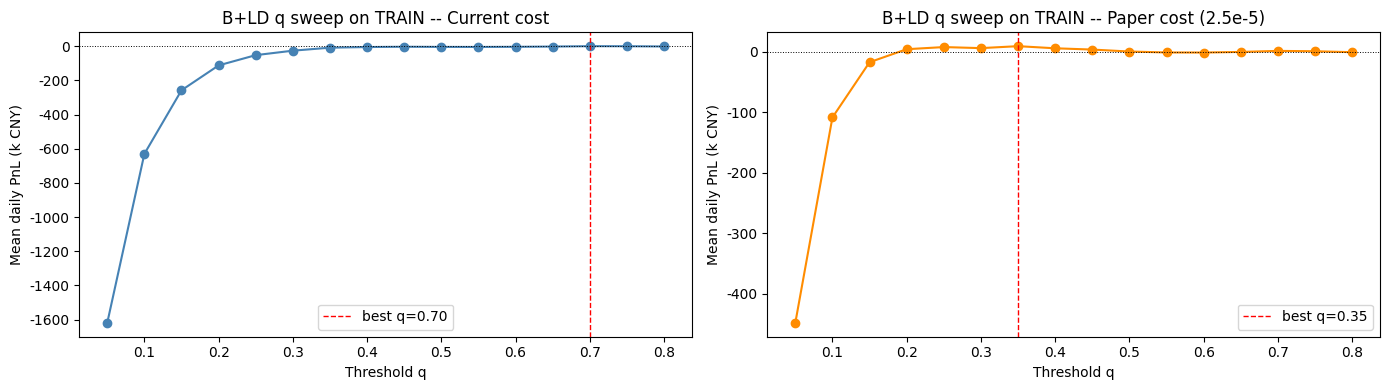

In [48]:
# 12.2 -- q sweep on train set only (k=5, uses existing all_features_B_enhanced)
_q_values_12 = [round(0.05 * i, 2) for i in range(1, 17)]  # 0.05 .. 0.80

_sweep_train_12 = dict(
    features_df=_feats_train_12,
    feature_cols=FEATURE_COLS_B_ENH,
    target_col=TARGET_COL,
    day_col=DAY_COL, session_col=SESSION_COL,
    bid_col=BID_COL, ask_col=ASK_COL, time_col=TIME_COL,
    q_values=_q_values_12,
    contract_multiplier=CONTRACT_MULT,
    trading_hours=TRADING_HOURS,
    output_dir=None,
)

print("=== q sweep on TRAIN (current cost) ===")
sweep_12_current = run_parameter_sweep(**_sweep_train_12,
    tr_cost_open=TR_COST_OPEN, tr_cost_close=TR_COST_CLOSE)

print("\n=== q sweep on TRAIN (paper cost 2.5e-5) ===")
sweep_12_paper = run_parameter_sweep(**_sweep_train_12,
    tr_cost_open=TR_COST_PAPER, tr_cost_close=TR_COST_PAPER)

best_q_12_current = float(sweep_12_current.loc[sweep_12_current['mean_daily_pnl'].idxmax(), 'q'])
best_q_12_paper   = float(sweep_12_paper.loc[sweep_12_paper['mean_daily_pnl'].idxmax(), 'q'])
print(f"\nTrain-optimal q -- current: {best_q_12_current:.2f}  paper: {best_q_12_paper:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, sw, q_best, label, color in zip(
    axes,
    [sweep_12_current, sweep_12_paper],
    [best_q_12_current, best_q_12_paper],
    ['Current cost', 'Paper cost (2.5e-5)'],
    ['steelblue', 'darkorange'],
):
    ax.plot(sw['q'], sw['mean_daily_pnl'] / 1e3, 'o-', color=color, linewidth=1.5)
    ax.axvline(q_best, color='red', linestyle='--', linewidth=1, label=f'best q={q_best:.2f}')
    ax.axhline(0, color='black', linewidth=0.7, linestyle=':')
    ax.set_xlabel('Threshold q')
    ax.set_ylabel('Mean daily PnL (k CNY)')
    ax.set_title(f'B+LD q sweep on TRAIN -- {label}')
    ax.legend()
plt.tight_layout()
plt.show()


  k=5 ... done
  k=10 ... done
  k=15 ... done
  k=20 ... done
  k=25 ... done
  k=30 ... done
  k=35 ... done
  k=40 ... done
  k=45 ... done
  k=50 ... done

Train-optimal k -- current: 10  paper: 5


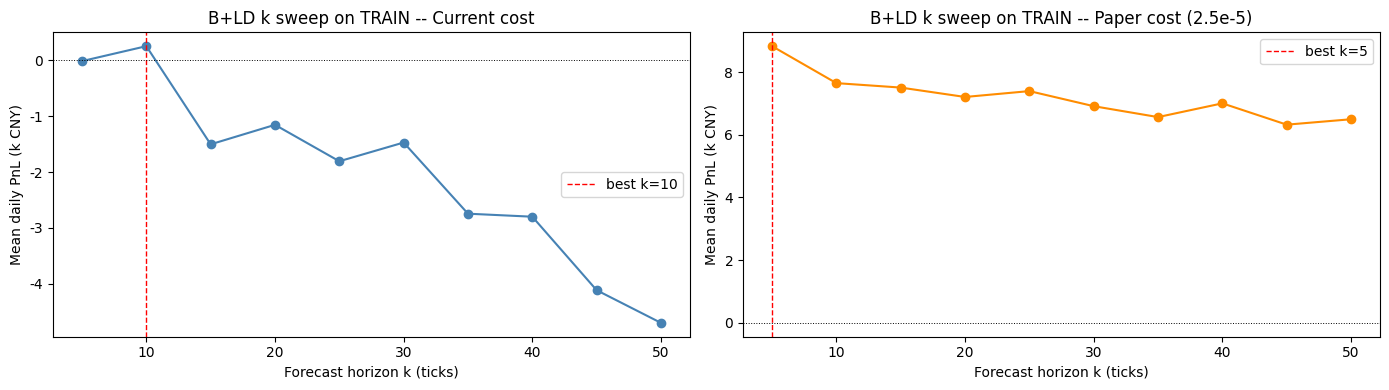

In [49]:
# 12.3 -- k sweep on train set only (at train-optimal q per cost)
K_VALUES_12 = list(range(5, 55, 5))   # 5, 10, ..., 50

_bt_k12 = dict(
    feature_cols=FEATURE_COLS_B_ENH,
    target_col=TARGET_COL,
    day_col=DAY_COL, session_col=SESSION_COL,
    bid_col=BID_COL, ask_col=ASK_COL, time_col=TIME_COL,
    contract_multiplier=CONTRACT_MULT,
    trading_hours=TRADING_HOURS,
)

k_rec_12_current, k_rec_12_paper = [], []

for k_val in K_VALUES_12:
    print(f"  k={k_val} ...", end=' ', flush=True)
    feats_k = (
        df_main[df_main[DAY_COL].isin(TRAIN_DAYS_12)]
        .groupby([DAY_COL, SESSION_COL], group_keys=False)
        .apply(lambda g, k=k_val: build_features_B_enhanced(g, k=k))
        .join(df_main.loc[df_main[DAY_COL].isin(TRAIN_DAYS_12), _join_cols])
        .reset_index(drop=True)
    )
    for q_best, cost_kw, records in [
        (best_q_12_current,
         dict(tr_cost_open=TR_COST_OPEN,   tr_cost_close=TR_COST_CLOSE),  k_rec_12_current),
        (best_q_12_paper,
         dict(tr_cost_open=TR_COST_PAPER,  tr_cost_close=TR_COST_PAPER),  k_rec_12_paper),
    ]:
        res = run_backtest(features_df=feats_k, threshold=q_best, **_bt_k12, **cost_kw)
        m   = compute_performance_metrics(res, output_dir=None, verbose=False)
        records.append({'k': k_val, **m})
    print("done")

df_k12_current = pd.DataFrame(k_rec_12_current)
df_k12_paper   = pd.DataFrame(k_rec_12_paper)

best_k_12_current = int(df_k12_current.loc[df_k12_current['mean_daily_pnl'].idxmax(), 'k'])
best_k_12_paper   = int(df_k12_paper.loc[df_k12_paper['mean_daily_pnl'].idxmax(), 'k'])
print(f"\nTrain-optimal k -- current: {best_k_12_current}  paper: {best_k_12_paper}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, df_k, k_best, label, color in zip(
    axes,
    [df_k12_current, df_k12_paper],
    [best_k_12_current, best_k_12_paper],
    ['Current cost', 'Paper cost (2.5e-5)'],
    ['steelblue', 'darkorange'],
):
    ax.plot(df_k['k'], df_k['mean_daily_pnl'] / 1e3, 'o-', color=color, linewidth=1.5)
    ax.axvline(k_best, color='red', linestyle='--', linewidth=1, label=f'best k={k_best}')
    ax.axhline(0, color='black', linewidth=0.7, linestyle=':')
    ax.set_xlabel('Forecast horizon k (ticks)')
    ax.set_ylabel('Mean daily PnL (k CNY)')
    ax.set_title(f'B+LD k sweep on TRAIN -- {label}')
    ax.legend()
plt.tight_layout()
plt.show()


Building features: current k=10, paper k=5 ...
Running backtests ...


,Days,Annualised Sharpe,Mean daily PnL (CNY),Std daily PnL (CNY),Win rate (% days>0),Total trades
Set,,,,,,
"TRAIN current (k=10, q=0.70)",38,0.534,256.1,7607.6,39.5,221
"TEST current (k=10, q=0.70)",20,-7.371,-1807.6,3893.0,5.0,39
"TRAIN paper (k=5, q=0.35)",38,11.137,8825.6,12580.1,78.9,2424
"TEST paper (k=5, q=0.35)",20,-3.976,-2398.0,9573.7,30.0,348


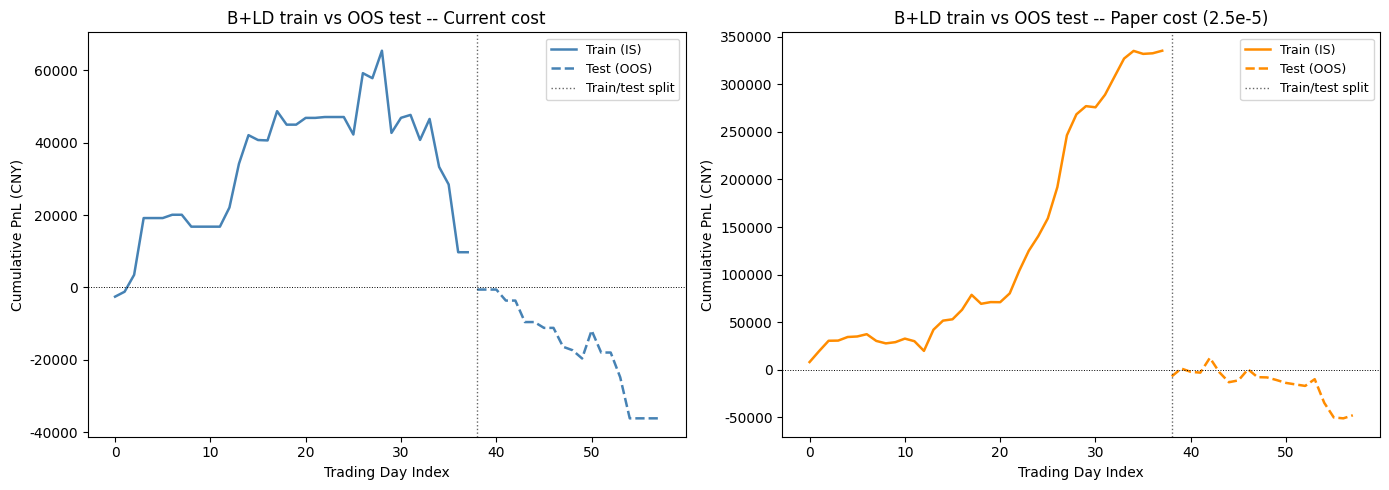

In [50]:
# 12.4 -- OOS test: evaluate train-optimal (k, q) on held-out test days
# Prepend last training day as seed so walk-forward has a reference for test day 0.
_last_train_12 = TRAIN_DAYS_12[-1]
_test_seed_12  = [_last_train_12] + list(TEST_DAYS_12)

def _build_test_feats_12(k):
    return (
        df_main[df_main[DAY_COL].isin(_test_seed_12)]
        .groupby([DAY_COL, SESSION_COL], group_keys=False)
        .apply(lambda g, _k=k: build_features_B_enhanced(g, k=_k))
        .join(df_main.loc[df_main[DAY_COL].isin(_test_seed_12), _join_cols])
        .reset_index(drop=True)
    )

def _build_train_feats_12(k):
    return (
        df_main[df_main[DAY_COL].isin(TRAIN_DAYS_12)]
        .groupby([DAY_COL, SESSION_COL], group_keys=False)
        .apply(lambda g, _k=k: build_features_B_enhanced(g, k=_k))
        .join(df_main.loc[df_main[DAY_COL].isin(TRAIN_DAYS_12), _join_cols])
        .reset_index(drop=True)
    )

_bt_final_12 = dict(
    feature_cols=FEATURE_COLS_B_ENH,
    target_col=TARGET_COL,
    day_col=DAY_COL, session_col=SESSION_COL,
    bid_col=BID_COL, ask_col=ASK_COL, time_col=TIME_COL,
    contract_multiplier=CONTRACT_MULT,
    trading_hours=TRADING_HOURS,
)

print(f"Building features: current k={best_k_12_current}, paper k={best_k_12_paper} ...")
_ftest_cur  = _build_test_feats_12(best_k_12_current)
_ftest_pap  = _build_test_feats_12(best_k_12_paper)
_ftrain_cur = _build_train_feats_12(best_k_12_current)
_ftrain_pap = _build_train_feats_12(best_k_12_paper)

print("Running backtests ...")
_res_test_cur  = {d: v for d, v in run_backtest(
    features_df=_ftest_cur,  threshold=best_q_12_current,
    tr_cost_open=TR_COST_OPEN, tr_cost_close=TR_COST_CLOSE, **_bt_final_12
).items() if d in TEST_DAYS_12}

_res_test_pap  = {d: v for d, v in run_backtest(
    features_df=_ftest_pap,  threshold=best_q_12_paper,
    tr_cost_open=TR_COST_PAPER, tr_cost_close=TR_COST_PAPER, **_bt_final_12
).items() if d in TEST_DAYS_12}

_res_train_cur = run_backtest(
    features_df=_ftrain_cur, threshold=best_q_12_current,
    tr_cost_open=TR_COST_OPEN, tr_cost_close=TR_COST_CLOSE, **_bt_final_12)

_res_train_pap = run_backtest(
    features_df=_ftrain_pap, threshold=best_q_12_paper,
    tr_cost_open=TR_COST_PAPER, tr_cost_close=TR_COST_PAPER, **_bt_final_12)

def _metrics_12(res, label):
    m    = compute_performance_metrics(res, output_dir=None, verbose=False)
    pnls = [res[d]['daily_pnl'] for d in sorted(res)]
    return {
        'Set':                   label,
        'Days':                  len(pnls),
        'Annualised Sharpe':     round(m['annualized_sharpe'], 3),
        'Mean daily PnL (CNY)':  round(m['mean_daily_pnl'],    1),
        'Std daily PnL (CNY)':   round(m['std_daily_pnl'],     1),
        'Win rate (% days>0)':   round(100 * sum(p > 0 for p in pnls) / len(pnls), 1),
        'Total trades':          int(m['n_trades']),
    }

df_oos_12 = pd.DataFrame([
    _metrics_12(_res_train_cur, f'TRAIN  current (k={best_k_12_current}, q={best_q_12_current:.2f})'),
    _metrics_12(_res_test_cur,  f'TEST   current (k={best_k_12_current}, q={best_q_12_current:.2f})'),
    _metrics_12(_res_train_pap, f'TRAIN  paper   (k={best_k_12_paper},   q={best_q_12_paper:.2f})'),
    _metrics_12(_res_test_pap,  f'TEST   paper   (k={best_k_12_paper},   q={best_q_12_paper:.2f})'),
]).set_index('Set')
display(df_oos_12)

# Cumulative PnL: train (solid) + test (dashed), split line marked
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, res_tr, res_te, label, color in zip(
    axes,
    [_res_train_cur, _res_train_pap],
    [_res_test_cur,  _res_test_pap],
    ['Current cost', 'Paper cost (2.5e-5)'],
    ['steelblue', 'darkorange'],
):
    tr_days = sorted(res_tr.keys())
    te_days = sorted(res_te.keys())
    tr_pnl  = np.array([res_tr[d]['daily_pnl'] for d in tr_days])
    te_pnl  = np.array([res_te[d]['daily_pnl'] for d in te_days])
    n_tr = len(tr_days)
    ax.plot(range(n_tr), np.cumsum(tr_pnl),
            color=color, linestyle='-', linewidth=1.8, label='Train (IS)')
    ax.plot(range(n_tr, n_tr + len(te_days)), np.cumsum(te_pnl),
            color=color, linestyle='--', linewidth=1.8, label='Test (OOS)')
    ax.axvline(n_tr, color='black', linewidth=1, linestyle=':', alpha=0.6, label='Train/test split')
    ax.axhline(0, color='black', linewidth=0.7, linestyle=':')
    ax.set_xlabel('Trading Day Index')
    ax.set_ylabel('Cumulative PnL (CNY)')
    ax.set_title(f'B+LD train vs OOS test -- {label}')
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## 13. B+LD Walk-Forward Optimisation (WFO)

Addresses the in-sample overfitting from Section 12 by using a **fixed rolling window**:

```
|-- train 30d --|-- OOS 10d --|
           |-- train 30d --|-- OOS 10d --|
                      |-- train 30d --|-- OOS 10d --|
```

Each fold:
1. Sweep q on training days (k=5) to find `best_q`
2. Sweep k on training days (at `best_q`) to find `best_k`
3. Evaluate (best_q, best_k) blind on the OOS window

All OOS windows are concatenated into a single out-of-sample track record.
Run under both **paper** (2.5e-5) and **current** cost structures.


In [51]:
# 13.1 -- WFO parameters and fold generation
WFO_TRAIN = 30   # training window length (trading days)
WFO_OOS   = 10   # OOS window length
WFO_STEP  = 10   # roll-forward step

_wfo_days = sorted(df_main[DAY_COL].unique())
print(f"Total trading days available: {len(_wfo_days)}")

folds = []
i = 0
while True:
    tr_start = i * WFO_STEP
    tr_end   = tr_start + WFO_TRAIN
    oos_end  = tr_end + WFO_OOS
    if tr_end >= len(_wfo_days):
        break
    train_days = _wfo_days[tr_start:tr_end]
    oos_days   = _wfo_days[tr_end:min(oos_end, len(_wfo_days))]
    if not oos_days:
        break
    folds.append((train_days, oos_days))
    i += 1

print(f"Generated {len(folds)} folds:")
for fi, (tr, oos) in enumerate(folds):
    print(f"  Fold {fi+1}: train {tr[0]}-{tr[-1]} ({len(tr)}d)  OOS {oos[0]}-{oos[-1]} ({len(oos)}d)")


Total trading days available: 59
Generated 3 folds:
  Fold 1: train 20260203-20260324 (30d)  OOS 20260325-20260408 (10d)
  Fold 2: train 20260225-20260408 (30d)  OOS 20260409-20260422 (10d)
  Fold 3: train 20260311-20260422 (30d)  OOS 20260423-20260508 (9d)


In [52]:
# 13.2 -- WFO main loop: sweep q and k on train, evaluate on OOS
WFO_Q_VALUES = [round(0.05 * i, 2) for i in range(1, 21)]  # 0.05 .. 1.00
WFO_K_VALUES = list(range(5, 35, 5))                         # 5, 10, ..., 30

_bt_wfo = dict(
    feature_cols=FEATURE_COLS_B_ENH,
    target_col=TARGET_COL,
    day_col=DAY_COL, session_col=SESSION_COL,
    bid_col=BID_COL, ask_col=ASK_COL, time_col=TIME_COL,
    contract_multiplier=CONTRACT_MULT,
    trading_hours=TRADING_HOURS,
)
_cost_schemes = {
    'current': dict(tr_cost_open=TR_COST_OPEN,  tr_cost_close=TR_COST_CLOSE),
    'paper':   dict(tr_cost_open=TR_COST_PAPER, tr_cost_close=TR_COST_PAPER),
}

# Collect per-fold results: {cost_label: {day: day_result}}
wfo_oos_results = {c: {} for c in _cost_schemes}
wfo_fold_log    = []   # record chosen (q, k) per fold per cost

for fi, (train_days, oos_days) in enumerate(folds):
    print(f"\n=== Fold {fi+1}/{len(folds)}: train {train_days[0]}-{train_days[-1]}, OOS {oos_days[0]}-{oos_days[-1]} ===")

    # --- filter train features (k=5) for q sweep ---
    feats_tr_k5 = all_features_B_enhanced[
        all_features_B_enhanced[DAY_COL].isin(train_days)
    ].reset_index(drop=True)

    fold_entry = {'fold': fi + 1, 'train_start': train_days[0], 'train_end': train_days[-1],
                  'oos_start': oos_days[0], 'oos_end': oos_days[-1]}

    for cost_label, cost_kw in _cost_schemes.items():
        # Step 1: q sweep on train at k=5
        sw = run_parameter_sweep(
            features_df=feats_tr_k5, feature_cols=FEATURE_COLS_B_ENH,
            target_col=TARGET_COL, day_col=DAY_COL, session_col=SESSION_COL,
            bid_col=BID_COL, ask_col=ASK_COL, time_col=TIME_COL,
            q_values=WFO_Q_VALUES, contract_multiplier=CONTRACT_MULT,
            trading_hours=TRADING_HOURS, output_dir=None, **cost_kw,
        )
        best_q = float(sw.loc[sw['mean_daily_pnl'].idxmax(), 'q'])

        # Step 2: k sweep on train at best_q
        k_pnls = []
        for k_val in WFO_K_VALUES:
            feats_k = (
                df_main[df_main[DAY_COL].isin(train_days)]
                .groupby([DAY_COL, SESSION_COL], group_keys=False)
                .apply(lambda g, k=k_val: build_features_B_enhanced(g, k=k))
                .join(df_main.loc[df_main[DAY_COL].isin(train_days), _join_cols])
                .reset_index(drop=True)
            )
            res_k = run_backtest(features_df=feats_k, threshold=best_q, **_bt_wfo, **cost_kw)
            m_k   = compute_performance_metrics(res_k, output_dir=None, verbose=False)
            k_pnls.append((k_val, m_k['mean_daily_pnl']))
        best_k = max(k_pnls, key=lambda x: x[1])[0]

        print(f"  [{cost_label}] best_q={best_q:.2f}  best_k={best_k}")
        fold_entry[f'best_q_{cost_label}'] = best_q
        fold_entry[f'best_k_{cost_label}'] = best_k

        # Step 3: OOS evaluation at (best_k, best_q)
        oos_seed_days = [train_days[-1]] + list(oos_days)
        feats_oos = (
            df_main[df_main[DAY_COL].isin(oos_seed_days)]
            .groupby([DAY_COL, SESSION_COL], group_keys=False)
            .apply(lambda g, k=best_k: build_features_B_enhanced(g, k=k))
            .join(df_main.loc[df_main[DAY_COL].isin(oos_seed_days), _join_cols])
            .reset_index(drop=True)
        )
        res_oos_all = run_backtest(features_df=feats_oos, threshold=best_q, **_bt_wfo, **cost_kw)
        # Keep only the true OOS days (drop seed day)
        for d in oos_days:
            if d in res_oos_all:
                wfo_oos_results[cost_label][d] = res_oos_all[d]

    wfo_fold_log.append(fold_entry)

df_fold_log = pd.DataFrame(wfo_fold_log)
print("\n=== Fold parameter log ===")
print(df_fold_log.to_string(index=False))



=== Fold 1/3: train 20260203-20260324, OOS 20260325-20260408 ===
Precomputing signals for parameter sweep...
Signals cached for 58 (day, session) pairs.
  q=0.050  mean_daily_pnl=-1,629,898  t=-51.614  sharpe=-152.148
  q=0.100  mean_daily_pnl=  -636,224  t=-19.738  sharpe=-58.184
  q=0.150  mean_daily_pnl=  -264,004  t=-11.730  sharpe=-34.577
  q=0.200  mean_daily_pnl=  -114,993  t=-8.350  sharpe=-24.615
  q=0.250  mean_daily_pnl=   -54,700  t=-6.105  sharpe=-17.996
  q=0.300  mean_daily_pnl=   -27,204  t=-4.551  sharpe=-13.415
  q=0.350  mean_daily_pnl=    -9,825  t=-2.893  sharpe=-8.527
  q=0.400  mean_daily_pnl=    -5,945  t=-1.989  sharpe=-5.864
  q=0.450  mean_daily_pnl=    -3,349  t=-1.269  sharpe=-3.739
  q=0.500  mean_daily_pnl=    -4,203  t=-1.553  sharpe=-4.577
  q=0.550  mean_daily_pnl=    -4,536  t=-1.805  sharpe=-5.321
  q=0.600  mean_daily_pnl=    -3,064  t=-1.476  sharpe=-4.351
  q=0.650  mean_daily_pnl=      -497  t=-0.254  sharpe=-0.750
  q=0.700  mean_daily_pnl=    

,OOS days,Annualised Sharpe,Mean daily PnL (CNY),Std daily PnL (CNY),Win rate (% days>0),Total trades
Scenario,,,,,,
WFO OOS -- current cost,29,-7.255,-2798.3,6123.2,10.3,69
WFO OOS -- paper cost (2.5e-5),29,1.017,651.8,10176.3,44.8,783


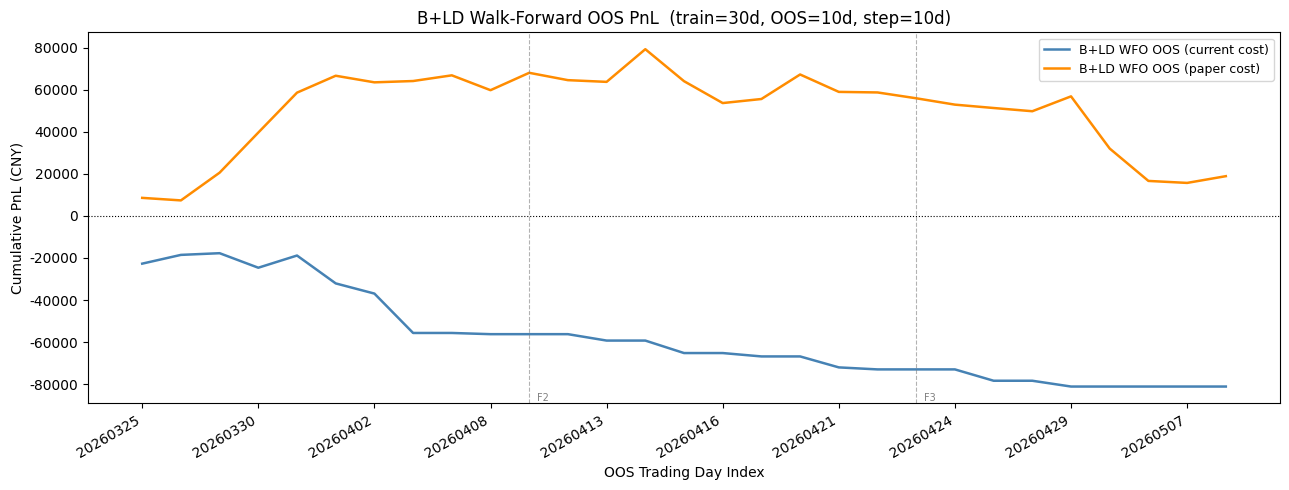


=== Parameter stability across folds ===
 fold  best_q_current  best_k_current  best_q_paper  best_k_paper
    1             0.7              10          0.35             5
    2             0.7              10          0.35             5
    3             1.0              15          0.35             5


In [53]:
# 13.3 -- WFO OOS results: metrics table + cumulative PnL

def _wfo_metrics(res, label):
    m    = compute_performance_metrics(res, output_dir=None, verbose=False)
    pnls = [res[d]['daily_pnl'] for d in sorted(res)]
    return {
        'Scenario':              label,
        'OOS days':              len(pnls),
        'Annualised Sharpe':     round(m['annualized_sharpe'], 3),
        'Mean daily PnL (CNY)':  round(m['mean_daily_pnl'],    1),
        'Std daily PnL (CNY)':   round(m['std_daily_pnl'],     1),
        'Win rate (% days>0)':   round(100 * sum(p > 0 for p in pnls) / len(pnls), 1),
        'Total trades':          int(m['n_trades']),
    }

df_wfo = pd.DataFrame([
    _wfo_metrics(wfo_oos_results['current'], f'WFO OOS -- current cost'),
    _wfo_metrics(wfo_oos_results['paper'],   f'WFO OOS -- paper cost (2.5e-5)'),
]).set_index('Scenario')
display(df_wfo)

# Cumulative PnL with fold boundaries marked
fig, ax = plt.subplots(figsize=(13, 5))
for cost_label, color in [('current', 'steelblue'), ('paper', 'darkorange')]:
    oos_days_sorted = sorted(wfo_oos_results[cost_label].keys())
    pnl = np.array([wfo_oos_results[cost_label][d]['daily_pnl'] for d in oos_days_sorted])
    ax.plot(range(len(oos_days_sorted)), np.cumsum(pnl),
            color=color, linewidth=1.8, label=f'B+LD WFO OOS ({cost_label} cost)')

# Mark fold boundaries
_oos_days_ref = sorted(wfo_oos_results['current'].keys())
for fi, (_, oos_days) in enumerate(folds):
    boundary = next((i for i, d in enumerate(_oos_days_ref) if d == oos_days[0]), None)
    if boundary is not None and boundary > 0:
        ax.axvline(boundary, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)
        ax.text(boundary + 0.2, ax.get_ylim()[0] if ax.get_ylim()[0] != 0 else 0,
                f'F{fi+1}', fontsize=7, color='gray', va='bottom')

ax.axhline(0, color='black', linewidth=0.8, linestyle=':')
ax.set_xlabel('OOS Trading Day Index')
ax.set_ylabel('Cumulative PnL (CNY)')
ax.set_title(f'B+LD Walk-Forward OOS PnL  (train={WFO_TRAIN}d, OOS={WFO_OOS}d, step={WFO_STEP}d)')
ax.legend(fontsize=9)
_step_x = max(1, len(_oos_days_ref) // 8)
ax.set_xticks(range(0, len(_oos_days_ref), _step_x))
ax.set_xticklabels([str(_oos_days_ref[j]) for j in range(0, len(_oos_days_ref), _step_x)],
                   rotation=30, ha='right')
plt.tight_layout()
plt.show()

# Summary: chosen (q, k) stability across folds
print("\n=== Parameter stability across folds ===")
print(df_fold_log[[
    'fold',
    'best_q_current', 'best_k_current',
    'best_q_paper',   'best_k_paper',
]].to_string(index=False))


In [54]:
# 13.4 -- WFO for Strategy B (no LD) -- same folds and sweep ranges as 13.2
_bt_wfo_b = dict(
    feature_cols=FEATURE_COLS_B,
    target_col=TARGET_COL,
    day_col=DAY_COL, session_col=SESSION_COL,
    bid_col=BID_COL, ask_col=ASK_COL, time_col=TIME_COL,
    contract_multiplier=CONTRACT_MULT,
    trading_hours=TRADING_HOURS,
)

wfo_oos_results_b = {c: {} for c in _cost_schemes}
wfo_fold_log_b    = []

for fi, (train_days, oos_days) in enumerate(folds):
    print(f"\n=== Fold {fi+1}/{len(folds)}: train {train_days[0]}-{train_days[-1]}, OOS {oos_days[0]}-{oos_days[-1]} ===")

    feats_tr_k5_b = all_features_B[
        all_features_B[DAY_COL].isin(train_days)
    ].reset_index(drop=True)

    fold_entry = {'fold': fi + 1}

    for cost_label, cost_kw in _cost_schemes.items():
        # Step 1: q sweep on train (k=5)
        sw = run_parameter_sweep(
            features_df=feats_tr_k5_b, feature_cols=FEATURE_COLS_B,
            target_col=TARGET_COL, day_col=DAY_COL, session_col=SESSION_COL,
            bid_col=BID_COL, ask_col=ASK_COL, time_col=TIME_COL,
            q_values=WFO_Q_VALUES, contract_multiplier=CONTRACT_MULT,
            trading_hours=TRADING_HOURS, output_dir=None, **cost_kw,
        )
        best_q = float(sw.loc[sw['mean_daily_pnl'].idxmax(), 'q'])

        # Step 2: k sweep on train at best_q
        k_pnls = []
        for k_val in WFO_K_VALUES:
            feats_k = (
                df_main[df_main[DAY_COL].isin(train_days)]
                .groupby([DAY_COL, SESSION_COL], group_keys=False)
                .apply(lambda g, k=k_val: build_feature_matrix_B(g, k=k))
                .join(df_main.loc[df_main[DAY_COL].isin(train_days),
                                  [DAY_COL, SESSION_COL, BID_COL, ASK_COL, 'MidPrice', TIME_COL]])
                .reset_index(drop=True)
            )
            res_k = run_backtest(features_df=feats_k, threshold=best_q, **_bt_wfo_b, **cost_kw)
            m_k   = compute_performance_metrics(res_k, output_dir=None, verbose=False)
            k_pnls.append((k_val, m_k['mean_daily_pnl']))
        best_k = max(k_pnls, key=lambda x: x[1])[0]

        print(f"  [{cost_label}] best_q={best_q:.2f}  best_k={best_k}")
        fold_entry[f'best_q_{cost_label}'] = best_q
        fold_entry[f'best_k_{cost_label}'] = best_k

        # Step 3: OOS evaluation
        oos_seed_days = [train_days[-1]] + list(oos_days)
        feats_oos = (
            df_main[df_main[DAY_COL].isin(oos_seed_days)]
            .groupby([DAY_COL, SESSION_COL], group_keys=False)
            .apply(lambda g, k=best_k: build_feature_matrix_B(g, k=k))
            .join(df_main.loc[df_main[DAY_COL].isin(oos_seed_days),
                              [DAY_COL, SESSION_COL, BID_COL, ASK_COL, 'MidPrice', TIME_COL]])
            .reset_index(drop=True)
        )
        res_oos_all = run_backtest(features_df=feats_oos, threshold=best_q, **_bt_wfo_b, **cost_kw)
        for d in oos_days:
            if d in res_oos_all:
                wfo_oos_results_b[cost_label][d] = res_oos_all[d]

    wfo_fold_log_b.append(fold_entry)

df_fold_log_b = pd.DataFrame(wfo_fold_log_b)
print("\n=== Strategy B fold parameter log ===")
print(df_fold_log_b.to_string(index=False))



=== Fold 1/3: train 20260203-20260324, OOS 20260325-20260408 ===
Precomputing signals for parameter sweep...
Signals cached for 58 (day, session) pairs.
  q=0.050  mean_daily_pnl=-1,534,732  t=-45.965  sharpe=-135.498
  q=0.100  mean_daily_pnl=  -505,169  t=-19.120  sharpe=-56.363
  q=0.150  mean_daily_pnl=  -194,034  t=-11.237  sharpe=-33.126
  q=0.200  mean_daily_pnl=   -83,594  t=-7.638  sharpe=-22.515
  q=0.250  mean_daily_pnl=   -38,271  t=-5.747  sharpe=-16.942
  q=0.300  mean_daily_pnl=   -20,373  t=-4.331  sharpe=-12.766
  q=0.350  mean_daily_pnl=    -6,575  t=-1.990  sharpe=-5.866
  q=0.400  mean_daily_pnl=    -2,239  t=-0.918  sharpe=-2.706
  q=0.450  mean_daily_pnl=    -2,441  t=-1.061  sharpe=-3.128
  q=0.500  mean_daily_pnl=    -2,137  t=-1.177  sharpe=-3.471
  q=0.550  mean_daily_pnl=      -522  t=-0.446  sharpe=-1.316
  q=0.600  mean_daily_pnl=      -558  t=-0.447  sharpe=-1.318
  q=0.650  mean_daily_pnl=     1,659  t=1.009  sharpe=2.973
  q=0.700  mean_daily_pnl=      

,OOS days,Annualised Sharpe,Mean daily PnL (CNY),Std daily PnL (CNY),Win rate (% days>0),Total trades
Strategy,,,,,,
B current,29.0,-8.910,-4145.1,7385.1,20.7,98.0
B+LD current,29.0,-7.255,-2798.3,6123.2,10.3,69.0
B paper,29.0,0.824,509.0,9801.8,51.7,636.0
B+LD paper,29.0,1.017,651.8,10176.3,44.8,783.0


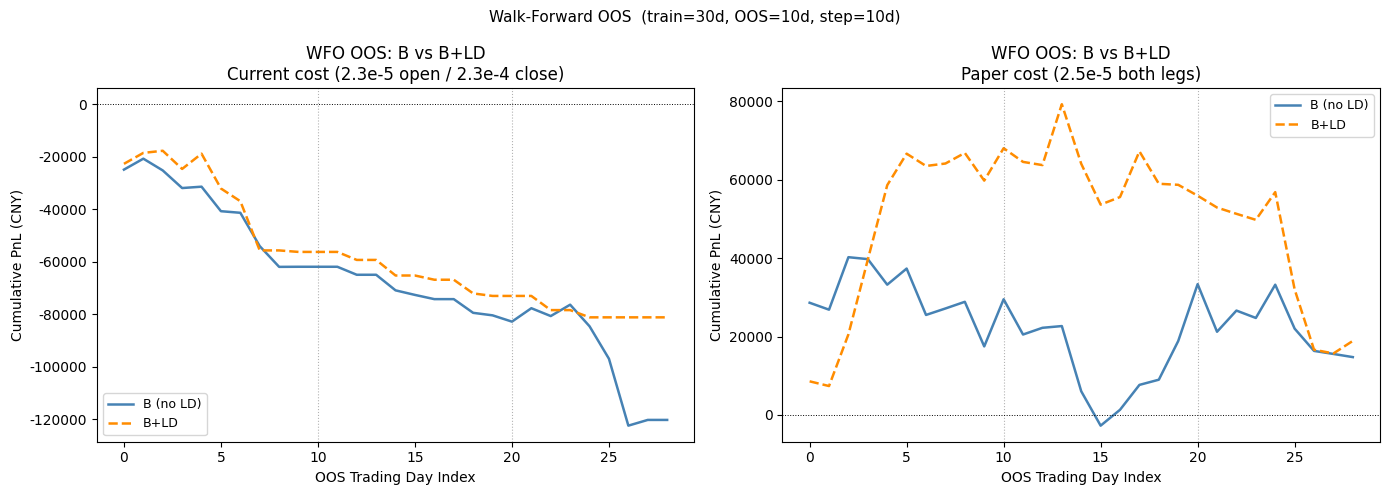

In [55]:
# 13.5 -- B vs B+LD WFO OOS comparison

def _m(res):
    m    = compute_performance_metrics(res, output_dir=None, verbose=False)
    pnls = [res[d]['daily_pnl'] for d in sorted(res)]
    return {
        'OOS days':              len(pnls),
        'Annualised Sharpe':     round(m['annualized_sharpe'], 3),
        'Mean daily PnL (CNY)':  round(m['mean_daily_pnl'],    1),
        'Std daily PnL (CNY)':   round(m['std_daily_pnl'],     1),
        'Win rate (% days>0)':   round(100 * sum(p > 0 for p in pnls) / len(pnls), 1),
        'Total trades':          int(m['n_trades']),
    }

rows = {
    'B     current': _m(wfo_oos_results_b['current']),
    'B+LD  current': _m(wfo_oos_results['current']),
    'B     paper':   _m(wfo_oos_results_b['paper']),
    'B+LD  paper':   _m(wfo_oos_results['paper']),
}
df_compare = pd.DataFrame(rows).T
df_compare.index.name = 'Strategy'
display(df_compare)

# Cumulative PnL comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, cost_label, title in [
    (axes[0], 'current', 'Current cost (2.3e-5 open / 2.3e-4 close)'),
    (axes[1], 'paper',   'Paper cost (2.5e-5 both legs)'),
]:
    for res, label, color, ls in [
        (wfo_oos_results_b[cost_label], 'B (no LD)',  'steelblue',  '-'),
        (wfo_oos_results[cost_label],   'B+LD',       'darkorange', '--'),
    ]:
        days = sorted(res.keys())
        pnl  = np.array([res[d]['daily_pnl'] for d in days])
        ax.plot(range(len(days)), np.cumsum(pnl),
                color=color, linestyle=ls, linewidth=1.8, label=label)

    # fold boundaries
    oos_ref = sorted(wfo_oos_results_b[cost_label].keys())
    for fi, (_, oos_days) in enumerate(folds):
        boundary = next((i for i, d in enumerate(oos_ref) if d == oos_days[0]), None)
        if boundary is not None and boundary > 0:
            ax.axvline(boundary, color='gray', linewidth=0.8, linestyle=':', alpha=0.6)

    ax.axhline(0, color='black', linewidth=0.7, linestyle=':')
    ax.set_xlabel('OOS Trading Day Index')
    ax.set_ylabel('Cumulative PnL (CNY)')
    ax.set_title(f'WFO OOS: B vs B+LD\n{title}')
    ax.legend(fontsize=9)

plt.suptitle(f'Walk-Forward OOS  (train={WFO_TRAIN}d, OOS={WFO_OOS}d, step={WFO_STEP}d)', fontsize=11)
plt.tight_layout()
plt.show()


## 14. Summary: In-Sample vs Out-of-Sample Performance

| Source | Method | Bias exposure |
|--------|--------|---------------|
| Sections 5–6 (A & B baseline) | Pre-specified q=0.20, k=5 from Shen (2015) | **None** — parameters fixed before data examination |
| Sections 8, 10 (sweep) | In-sample optimisation over full dataset | **High** — in-sample ceiling only |
| Section 12 (train/test) | 2/3 train sweep, 1/3 held-out evaluation | **Low** — OOS estimate but single split |
| Section 13 (WFO) | 30-day rolling train, 10-day OOS windows | **Minimal** — walk-forward OOS estimate |

### Key finding: parameter stability

The train/test split (Section 12) and walk-forward optimisation (Section 13) both show **material degradation** relative to the in-sample sweep — the optimal (q, k) found on training data does not generalise stably to the held-out period. This is consistent with the short effective sample size (~60–80 trading days per window) and the sensitivity of threshold-based strategies to noise.

### Implications for the main conclusions

1. **Signal validity** (A vs B at fixed q=0.20, k=5): this comparison is **not affected** by parameter selection bias. Both strategies use identical, pre-specified parameters.
2. **Profitability claims**: the in-sample sweep figures in Sections 8/10 should **not** be cited as expected live performance. The WFO Sharpe ratios in Section 13 are the appropriate out-of-sample estimates.
3. **Strategy A vs B+LD (WFO)**: the walk-forward results provide the most credible like-for-like comparison of the two strategies under realistic parameter uncertainty.

**Limitation**: even the WFO estimate is subject to look-ahead from the overall research process (model specification, feature selection) conducted before this notebook was written. A fully prospective test would require live deployment or a pre-registered evaluation protocol.